# How to Run the Notebook

To execute the notebook, run all cells sequentially from top to bottom.

It is important to first execute the cells containing the Berkeley-provided modules, as they define the necessary search algorithms and supporting functions used throughout the notebook.

Once these modules are loaded, the remaining cells can be run in order to reproduce all results, including path computations, visualizations, and performance outputs.


The following external libraries may need to be installed before running the notebook:

- numpy
- matplotlib


# Report

The report for the assigment is found as the last part of the notebook.

# UC Berkley Modules
The following blocks include the utils.py and search.py modules from the UC Berkeley AIMA Python repository. These provide the core data structures and search algorithms (such as A*, Uniform Cost Search, and Greedy Best-First Search) used in this assignment.

In [ ]:
#utils.py from berkley repository
"""Provides some utilities widely used by other modules"""

import bisect
import collections
import collections.abc
import functools
import heapq
import operator
import os.path
import random
from itertools import chain, combinations
from statistics import mean

import numpy as np


# ______________________________________________________________________________
# Functions on Sequences and Iterables


def sequence(iterable):
    """Converts iterable to sequence, if it is not already one."""
    return iterable if isinstance(iterable, collections.abc.Sequence) else tuple([iterable])


def remove_all(item, seq):
    """Return a copy of seq (or string) with all occurrences of item removed."""
    if isinstance(seq, str):
        return seq.replace(item, '')
    elif isinstance(seq, set):
        rest = seq.copy()
        rest.remove(item)
        return rest
    else:
        return [x for x in seq if x != item]


def unique(seq):
    """Remove duplicate elements from seq. Assumes hashable elements."""
    return list(set(seq))


def count(seq):
    """Count the number of items in sequence that are interpreted as true."""
    return sum(map(bool, seq))


def multimap(items):
    """Given (key, val) pairs, return {key: [val, ....], ...}."""
    result = collections.defaultdict(list)
    for (key, val) in items:
        result[key].append(val)
    return dict(result)


def multimap_items(mmap):
    """Yield all (key, val) pairs stored in the multimap."""
    for (key, vals) in mmap.items():
        for val in vals:
            yield key, val


def product(numbers):
    """Return the product of the numbers, e.g. product([2, 3, 10]) == 60"""
    result = 1
    for x in numbers:
        result *= x
    return result


def first(iterable, default=None):
    """Return the first element of an iterable; or default."""
    return next(iter(iterable), default)


def is_in(elt, seq):
    """Similar to (elt in seq), but compares with 'is', not '=='."""
    return any(x is elt for x in seq)


def mode(data):
    """Return the most common data item. If there are ties, return any one of them."""
    [(item, count)] = collections.Counter(data).most_common(1)
    return item


def power_set(iterable):
    """power_set([1,2,3]) --> (1,) (2,) (3,) (1,2) (1,3) (2,3) (1,2,3)"""
    s = list(iterable)
    return list(chain.from_iterable(combinations(s, r) for r in range(len(s) + 1)))[1:]


def extend(s, var, val):
    """Copy dict s and extend it by setting var to val; return copy."""
    return {**s, var: val}


def flatten(seqs):
    return sum(seqs, [])


# ______________________________________________________________________________
# argmin and argmax

identity = lambda x: x


def argmin_random_tie(seq, key=identity):
    """Return a minimum element of seq; break ties at random."""
    return min(shuffled(seq), key=key)


def argmax_random_tie(seq, key=identity):
    """Return an element with highest fn(seq[i]) score; break ties at random."""
    return max(shuffled(seq), key=key)


def shuffled(iterable):
    """Randomly shuffle a copy of iterable."""
    items = list(iterable)
    random.shuffle(items)
    return items


# ______________________________________________________________________________
# Statistical and mathematical functions


def histogram(values, mode=0, bin_function=None):
    """Return a list of (value, count) pairs, summarizing the input values.
    Sorted by increasing value, or if mode=1, by decreasing count.
    If bin_function is given, map it over values first."""
    if bin_function:
        values = map(bin_function, values)

    bins = {}
    for val in values:
        bins[val] = bins.get(val, 0) + 1

    if mode:
        return sorted(list(bins.items()), key=lambda x: (x[1], x[0]), reverse=True)
    else:
        return sorted(bins.items())


def dot_product(x, y):
    """Return the sum of the element-wise product of vectors x and y."""
    return sum(_x * _y for _x, _y in zip(x, y))


def element_wise_product(x, y):
    """Return vector as an element-wise product of vectors x and y."""
    assert len(x) == len(y)
    return np.multiply(x, y)


def matrix_multiplication(x, *y):
    """Return a matrix as a matrix-multiplication of x and arbitrary number of matrices *y."""

    result = x
    for _y in y:
        result = np.matmul(result, _y)

    return result


def vector_add(a, b):
    """Component-wise addition of two vectors."""
    return tuple(map(operator.add, a, b))


def scalar_vector_product(x, y):
    """Return vector as a product of a scalar and a vector"""
    return np.multiply(x, y)


def probability(p):
    """Return true with probability p."""
    return p > random.uniform(0.0, 1.0)


def weighted_sample_with_replacement(n, seq, weights):
    """Pick n samples from seq at random, with replacement, with the
    probability of each element in proportion to its corresponding
    weight."""
    sample = weighted_sampler(seq, weights)
    return [sample() for _ in range(n)]


def weighted_sampler(seq, weights):
    """Return a random-sample function that picks from seq weighted by weights."""
    totals = []
    for w in weights:
        totals.append(w + totals[-1] if totals else w)
    return lambda: seq[bisect.bisect(totals, random.uniform(0, totals[-1]))]


def weighted_choice(choices):
    """A weighted version of random.choice"""
    # NOTE: should be replaced by random.choices if we port to Python 3.6

    total = sum(w for _, w in choices)
    r = random.uniform(0, total)
    upto = 0
    for c, w in choices:
        if upto + w >= r:
            return c, w
        upto += w


def rounder(numbers, d=4):
    """Round a single number, or sequence of numbers, to d decimal places."""
    if isinstance(numbers, (int, float)):
        return round(numbers, d)
    else:
        constructor = type(numbers)  # Can be list, set, tuple, etc.
        return constructor(rounder(n, d) for n in numbers)


def num_or_str(x):  # TODO: rename as `atom`
    """The argument is a string; convert to a number if possible, or strip it."""
    try:
        return int(x)
    except ValueError:
        try:
            return float(x)
        except ValueError:
            return str(x).strip()


def euclidean_distance(x, y):
    return np.sqrt(sum((_x - _y) ** 2 for _x, _y in zip(x, y)))


def manhattan_distance(x, y):
    return sum(abs(_x - _y) for _x, _y in zip(x, y))


def hamming_distance(x, y):
    return sum(_x != _y for _x, _y in zip(x, y))


def cross_entropy_loss(x, y):
    return (-1.0 / len(x)) * sum(_x * np.log(_y) + (1 - _x) * np.log(1 - _y) for _x, _y in zip(x, y))


def mean_squared_error_loss(x, y):
    return (1.0 / len(x)) * sum((_x - _y) ** 2 for _x, _y in zip(x, y))


def rms_error(x, y):
    return np.sqrt(ms_error(x, y))


def ms_error(x, y):
    return mean((_x - _y) ** 2 for _x, _y in zip(x, y))


def mean_error(x, y):
    return mean(abs(_x - _y) for _x, _y in zip(x, y))


def mean_boolean_error(x, y):
    return mean(_x != _y for _x, _y in zip(x, y))


def normalize(dist):
    """Multiply each number by a constant such that the sum is 1.0"""
    if isinstance(dist, dict):
        total = sum(dist.values())
        for key in dist:
            dist[key] = dist[key] / total
            assert 0 <= dist[key] <= 1  # probabilities must be between 0 and 1
        return dist
    total = sum(dist)
    return [(n / total) for n in dist]


def random_weights(min_value, max_value, num_weights):
    return [random.uniform(min_value, max_value) for _ in range(num_weights)]


def sigmoid(x):
    """Return activation value of x with sigmoid function."""
    return 1 / (1 + np.exp(-x))


def sigmoid_derivative(value):
    return value * (1 - value)


def elu(x, alpha=0.01):
    return x if x > 0 else alpha * (np.exp(x) - 1)


def elu_derivative(value, alpha=0.01):
    return 1 if value > 0 else alpha * np.exp(value)


def tanh(x):
    return np.tanh(x)


def tanh_derivative(value):
    return 1 - (value ** 2)


def leaky_relu(x, alpha=0.01):
    return x if x > 0 else alpha * x


def leaky_relu_derivative(value, alpha=0.01):
    return 1 if value > 0 else alpha


def relu(x):
    return max(0, x)


def relu_derivative(value):
    return 1 if value > 0 else 0


def step(x):
    """Return activation value of x with sign function"""
    return 1 if x >= 0 else 0


def gaussian(mean, st_dev, x):
    """Given the mean and standard deviation of a distribution, it returns the probability of x."""
    return 1 / (np.sqrt(2 * np.pi) * st_dev) * np.e ** (-0.5 * (float(x - mean) / st_dev) ** 2)


def linear_kernel(x, y=None):
    if y is None:
        y = x
    return np.dot(x, y.T)


def polynomial_kernel(x, y=None, degree=2.0):
    if y is None:
        y = x
    return (1.0 + np.dot(x, y.T)) ** degree


def rbf_kernel(x, y=None, gamma=None):
    """Radial-basis function kernel (aka squared-exponential kernel)."""
    if y is None:
        y = x
    if gamma is None:
        gamma = 1.0 / x.shape[1]  # 1.0 / n_features
    return np.exp(-gamma * (-2.0 * np.dot(x, y.T) +
                            np.sum(x * x, axis=1).reshape((-1, 1)) + np.sum(y * y, axis=1).reshape((1, -1))))


# ______________________________________________________________________________
# Grid Functions


orientations = EAST, NORTH, WEST, SOUTH = [(1, 0), (0, 1), (-1, 0), (0, -1)]
turns = LEFT, RIGHT = (+1, -1)


def turn_heading(heading, inc, headings=orientations):
    return headings[(headings.index(heading) + inc) % len(headings)]


def turn_right(heading):
    return turn_heading(heading, RIGHT)


def turn_left(heading):
    return turn_heading(heading, LEFT)


def distance(a, b):
    """The distance between two (x, y) points."""
    xA, yA = a
    xB, yB = b
    return np.hypot((xA - xB), (yA - yB))


def distance_squared(a, b):
    """The square of the distance between two (x, y) points."""
    xA, yA = a
    xB, yB = b
    return (xA - xB) ** 2 + (yA - yB) ** 2


# ______________________________________________________________________________
# Misc Functions

class injection:
    """Dependency injection of temporary values for global functions/classes/etc.
    E.g., `with injection(DataBase=MockDataBase): ...`"""

    def __init__(self, **kwds):
        self.new = kwds

    def __enter__(self):
        self.old = {v: globals()[v] for v in self.new}
        globals().update(self.new)

    def __exit__(self, type, value, traceback):
        globals().update(self.old)


def memoize(fn, slot=None, maxsize=32):
    """Memoize fn: make it remember the computed value for any argument list.
    If slot is specified, store result in that slot of first argument.
    If slot is false, use lru_cache for caching the values."""
    if slot:
        def memoized_fn(obj, *args):
            if hasattr(obj, slot):
                return getattr(obj, slot)
            else:
                val = fn(obj, *args)
                setattr(obj, slot, val)
                return val
    else:
        @functools.lru_cache(maxsize=maxsize)
        def memoized_fn(*args):
            return fn(*args)

    return memoized_fn


def name(obj):
    """Try to find some reasonable name for the object."""
    return (getattr(obj, 'name', 0) or getattr(obj, '__name__', 0) or
            getattr(getattr(obj, '__class__', 0), '__name__', 0) or
            str(obj))


def isnumber(x):
    """Is x a number?"""
    return hasattr(x, '__int__')


def issequence(x):
    """Is x a sequence?"""
    return isinstance(x, collections.abc.Sequence)


def print_table(table, header=None, sep='   ', numfmt='{}'):
    """Print a list of lists as a table, so that columns line up nicely.
    header, if specified, will be printed as the first row.
    numfmt is the format for all numbers; you might want e.g. '{:.2f}'.
    (If you want different formats in different columns,
    don't use print_table.) sep is the separator between columns."""
    justs = ['rjust' if isnumber(x) else 'ljust' for x in table[0]]

    if header:
        table.insert(0, header)

    table = [[numfmt.format(x) if isnumber(x) else x for x in row]
             for row in table]

    sizes = list(map(lambda seq: max(map(len, seq)), list(zip(*[map(str, row) for row in table]))))

    for row in table:
        print(sep.join(getattr(str(x), j)(size) for (j, size, x) in zip(justs, sizes, row)))


def open_data(name, mode='r'):
    aima_root = os.path.dirname(__file__)
    aima_file = os.path.join(aima_root, *['aima-data', name])

    return open(aima_file, mode=mode)


def failure_test(algorithm, tests):
    """Grades the given algorithm based on how many tests it passes.
    Most algorithms have arbitrary output on correct execution, which is difficult
    to check for correctness. On the other hand, a lot of algorithms output something
    particular on fail (for example, False, or None).
    tests is a list with each element in the form: (values, failure_output)."""
    return mean(int(algorithm(x) != y) for x, y in tests)


# ______________________________________________________________________________
# Expressions

# See https://docs.python.org/3/reference/expressions.html#operator-precedence
# See https://docs.python.org/3/reference/datamodel.html#special-method-names

class Expr:
    """A mathematical expression with an operator and 0 or more arguments.
    op is a str like '+' or 'sin'; args are Expressions.
    Expr('x') or Symbol('x') creates a symbol (a nullary Expr).
    Expr('-', x) creates a unary; Expr('+', x, 1) creates a binary."""

    def __init__(self, op, *args):
        self.op = str(op)
        self.args = args

    # Operator overloads
    def __neg__(self):
        return Expr('-', self)

    def __pos__(self):
        return Expr('+', self)

    def __invert__(self):
        return Expr('~', self)

    def __add__(self, rhs):
        return Expr('+', self, rhs)

    def __sub__(self, rhs):
        return Expr('-', self, rhs)

    def __mul__(self, rhs):
        return Expr('*', self, rhs)

    def __pow__(self, rhs):
        return Expr('**', self, rhs)

    def __mod__(self, rhs):
        return Expr('%', self, rhs)

    def __and__(self, rhs):
        return Expr('&', self, rhs)

    def __xor__(self, rhs):
        return Expr('^', self, rhs)

    def __rshift__(self, rhs):
        return Expr('>>', self, rhs)

    def __lshift__(self, rhs):
        return Expr('<<', self, rhs)

    def __truediv__(self, rhs):
        return Expr('/', self, rhs)

    def __floordiv__(self, rhs):
        return Expr('//', self, rhs)

    def __matmul__(self, rhs):
        return Expr('@', self, rhs)

    def __or__(self, rhs):
        """Allow both P | Q, and P |'==>'| Q."""
        if isinstance(rhs, Expression):
            return Expr('|', self, rhs)
        else:
            return PartialExpr(rhs, self)

    # Reverse operator overloads
    def __radd__(self, lhs):
        return Expr('+', lhs, self)

    def __rsub__(self, lhs):
        return Expr('-', lhs, self)

    def __rmul__(self, lhs):
        return Expr('*', lhs, self)

    def __rdiv__(self, lhs):
        return Expr('/', lhs, self)

    def __rpow__(self, lhs):
        return Expr('**', lhs, self)

    def __rmod__(self, lhs):
        return Expr('%', lhs, self)

    def __rand__(self, lhs):
        return Expr('&', lhs, self)

    def __rxor__(self, lhs):
        return Expr('^', lhs, self)

    def __ror__(self, lhs):
        return Expr('|', lhs, self)

    def __rrshift__(self, lhs):
        return Expr('>>', lhs, self)

    def __rlshift__(self, lhs):
        return Expr('<<', lhs, self)

    def __rtruediv__(self, lhs):
        return Expr('/', lhs, self)

    def __rfloordiv__(self, lhs):
        return Expr('//', lhs, self)

    def __rmatmul__(self, lhs):
        return Expr('@', lhs, self)

    def __call__(self, *args):
        """Call: if 'f' is a Symbol, then f(0) == Expr('f', 0)."""
        if self.args:
            raise ValueError('Can only do a call for a Symbol, not an Expr')
        else:
            return Expr(self.op, *args)

    # Equality and repr
    def __eq__(self, other):
        """x == y' evaluates to True or False; does not build an Expr."""
        return isinstance(other, Expr) and self.op == other.op and self.args == other.args

    def __lt__(self, other):
        return isinstance(other, Expr) and str(self) < str(other)

    def __hash__(self):
        return hash(self.op) ^ hash(self.args)

    def __repr__(self):
        op = self.op
        args = [str(arg) for arg in self.args]
        if op.isidentifier():  # f(x) or f(x, y)
            return '{}({})'.format(op, ', '.join(args)) if args else op
        elif len(args) == 1:  # -x or -(x + 1)
            return op + args[0]
        else:  # (x - y)
            opp = (' ' + op + ' ')
            return '(' + opp.join(args) + ')'


# An 'Expression' is either an Expr or a Number.
# Symbol is not an explicit type; it is any Expr with 0 args.


Number = (int, float, complex)
Expression = (Expr, Number)


def Symbol(name):
    """A Symbol is just an Expr with no args."""
    return Expr(name)


def symbols(names):
    """Return a tuple of Symbols; names is a comma/whitespace delimited str."""
    return tuple(Symbol(name) for name in names.replace(',', ' ').split())


def subexpressions(x):
    """Yield the subexpressions of an Expression (including x itself)."""
    yield x
    if isinstance(x, Expr):
        for arg in x.args:
            yield from subexpressions(arg)


def arity(expression):
    """The number of sub-expressions in this expression."""
    if isinstance(expression, Expr):
        return len(expression.args)
    else:  # expression is a number
        return 0


# For operators that are not defined in Python, we allow new InfixOps:


class PartialExpr:
    """Given 'P |'==>'| Q, first form PartialExpr('==>', P), then combine with Q."""

    def __init__(self, op, lhs):
        self.op, self.lhs = op, lhs

    def __or__(self, rhs):
        return Expr(self.op, self.lhs, rhs)

    def __repr__(self):
        return "PartialExpr('{}', {})".format(self.op, self.lhs)


def expr(x):
    """Shortcut to create an Expression. x is a str in which:
    - identifiers are automatically defined as Symbols.
    - ==> is treated as an infix |'==>'|, as are <== and <=>.
    If x is already an Expression, it is returned unchanged. Example:
    >>> expr('P & Q ==> Q')
    ((P & Q) ==> Q)
    """
    return eval(expr_handle_infix_ops(x), defaultkeydict(Symbol)) if isinstance(x, str) else x


infix_ops = '==> <== <=>'.split()


def expr_handle_infix_ops(x):
    """Given a str, return a new str with ==> replaced by |'==>'|, etc.
    >>> expr_handle_infix_ops('P ==> Q')
    "P |'==>'| Q"
    """
    for op in infix_ops:
        x = x.replace(op, '|' + repr(op) + '|')
    return x


class defaultkeydict(collections.defaultdict):
    """Like defaultdict, but the default_factory is a function of the key.
    >>> d = defaultkeydict(len); d['four']
    4
    """

    def __missing__(self, key):
        self[key] = result = self.default_factory(key)
        return result


class hashabledict(dict):
    """Allows hashing by representing a dictionary as tuple of key:value pairs.
    May cause problems as the hash value may change during runtime."""

    def __hash__(self):
        return 1


# ______________________________________________________________________________
# Queues: Stack, FIFOQueue, PriorityQueue
# Stack and FIFOQueue are implemented as list and collection.deque
# PriorityQueue is implemented here


class PriorityQueue:
    """A Queue in which the minimum (or maximum) element (as determined by f and
    order) is returned first.
    If order is 'min', the item with minimum f(x) is
    returned first; if order is 'max', then it is the item with maximum f(x).
    Also supports dict-like lookup."""

    def __init__(self, order='min', f=lambda x: x):
        self.heap = []
        if order == 'min':
            self.f = f
        elif order == 'max':  # now item with max f(x)
            self.f = lambda x: -f(x)  # will be popped first
        else:
            raise ValueError("Order must be either 'min' or 'max'.")

    def append(self, item):
        """Insert item at its correct position."""
        heapq.heappush(self.heap, (self.f(item), item))

    def extend(self, items):
        """Insert each item in items at its correct position."""
        for item in items:
            self.append(item)

    def pop(self):
        """Pop and return the item (with min or max f(x) value)
        depending on the order."""
        if self.heap:
            return heapq.heappop(self.heap)[1]
        else:
            raise Exception('Trying to pop from empty PriorityQueue.')

    def __len__(self):
        """Return current capacity of PriorityQueue."""
        return len(self.heap)

    def __contains__(self, key):
        """Return True if the key is in PriorityQueue."""
        return any([item == key for _, item in self.heap])

    def __getitem__(self, key):
        """Returns the first value associated with key in PriorityQueue.
        Raises KeyError if key is not present."""
        for value, item in self.heap:
            if item == key:
                return value
        raise KeyError(str(key) + " is not in the priority queue")

    def __delitem__(self, key):
        """Delete the first occurrence of key."""
        try:
            del self.heap[[item == key for _, item in self.heap].index(True)]
        except ValueError:
            raise KeyError(str(key) + " is not in the priority queue")
        heapq.heapify(self.heap)


# ______________________________________________________________________________
# Useful Shorthands


class Bool(int):
    """Just like `bool`, except values display as 'T' and 'F' instead of 'True' and 'False'."""
    __str__ = __repr__ = lambda self: 'T' if self else 'F'


T = Bool(True)
F = Bool(False)


In [ ]:
#search.py from berkley repository
"""
Search (Chapters 3-4)

The way to use this code is to subclass Problem to create a class of problems,
then create problem instances and solve them with calls to the various search
functions.
"""

import sys
from collections import deque


class Problem:
    """The abstract class for a formal problem. You should subclass
    this and implement the methods actions and result, and possibly
    __init__, goal_test, and path_cost. Then you will create instances
    of your subclass and solve them with the various search functions."""

    def __init__(self, initial, goal=None):
        """The constructor specifies the initial state, and possibly a goal
        state, if there is a unique goal. Your subclass's constructor can add
        other arguments."""
        self.initial = initial
        self.goal = goal

    def actions(self, state):
        """Return the actions that can be executed in the given
        state. The result would typically be a list, but if there are
        many actions, consider yielding them one at a time in an
        iterator, rather than building them all at once."""
        raise NotImplementedError

    def result(self, state, action):
        """Return the state that results from executing the given
        action in the given state. The action must be one of
        self.actions(state)."""
        raise NotImplementedError

    def goal_test(self, state):
        """Return True if the state is a goal. The default method compares the
        state to self.goal or checks for state in self.goal if it is a
        list, as specified in the constructor. Override this method if
        checking against a single self.goal is not enough."""
        if isinstance(self.goal, list):
            return is_in(state, self.goal)
        else:
            return state == self.goal

    def path_cost(self, c, state1, action, state2):
        """Return the cost of a solution path that arrives at state2 from
        state1 via action, assuming cost c to get up to state1. If the problem
        is such that the path doesn't matter, this function will only look at
        state2. If the path does matter, it will consider c and maybe state1
        and action. The default method costs 1 for every step in the path."""
        return c + 1

    def value(self, state):
        """For optimization problems, each state has a value. Hill Climbing
        and related algorithms try to maximize this value."""
        raise NotImplementedError


# ______________________________________________________________________________


class Node:
    """A node in a search tree. Contains a pointer to the parent (the node
    that this is a successor of) and to the actual state for this node. Note
    that if a state is arrived at by two paths, then there are two nodes with
    the same state. Also includes the action that got us to this state, and
    the total path_cost (also known as g) to reach the node. Other functions
    may add an f and h value; see best_first_graph_search and astar_search for
    an explanation of how the f and h values are handled. You will not need to
    subclass this class."""

    def __init__(self, state, parent=None, action=None, path_cost=0):
        """Create a search tree Node, derived from a parent by an action."""
        self.state = state
        self.parent = parent
        self.action = action
        self.path_cost = path_cost
        self.depth = 0
        if parent:
            self.depth = parent.depth + 1

    def __repr__(self):
        return "<Node {}>".format(self.state)

    def __lt__(self, node):
        return self.state < node.state

    def expand(self, problem):
        """List the nodes reachable in one step from this node."""
        return [self.child_node(problem, action)
                for action in problem.actions(self.state)]

    def child_node(self, problem, action):
        """[Figure 3.10]"""
        next_state = problem.result(self.state, action)
        next_node = Node(next_state, self, action, problem.path_cost(self.path_cost, self.state, action, next_state))
        return next_node

    def solution(self):
        """Return the sequence of actions to go from the root to this node."""
        return [node.action for node in self.path()[1:]]

    def path(self):
        """Return a list of nodes forming the path from the root to this node."""
        node, path_back = self, []
        while node:
            path_back.append(node)
            node = node.parent
        return list(reversed(path_back))

    # We want for a queue of nodes in breadth_first_graph_search or
    # astar_search to have no duplicated states, so we treat nodes
    # with the same state as equal. [Problem: this may not be what you
    # want in other contexts.]

    def __eq__(self, other):
        return isinstance(other, Node) and self.state == other.state

    def __hash__(self):
        # We use the hash value of the state
        # stored in the node instead of the node
        # object itself to quickly search a node
        # with the same state in a Hash Table
        return hash(self.state)


# ______________________________________________________________________________


class SimpleProblemSolvingAgentProgram:
    """
    [Figure 3.1]
    Abstract framework for a problem-solving agent.
    """

    def __init__(self, initial_state=None):
        """State is an abstract representation of the state
        of the world, and seq is the list of actions required
        to get to a particular state from the initial state(root)."""
        self.state = initial_state
        self.seq = []

    def __call__(self, percept):
        """[Figure 3.1] Formulate a goal and problem, then
        search for a sequence of actions to solve it."""
        self.state = self.update_state(self.state, percept)
        if not self.seq:
            goal = self.formulate_goal(self.state)
            problem = self.formulate_problem(self.state, goal)
            self.seq = self.search(problem)
            if not self.seq:
                return None
        return self.seq.pop(0)

    def update_state(self, state, percept):
        raise NotImplementedError

    def formulate_goal(self, state):
        raise NotImplementedError

    def formulate_problem(self, state, goal):
        raise NotImplementedError

    def search(self, problem):
        raise NotImplementedError


# ______________________________________________________________________________
# Uninformed Search algorithms


def breadth_first_tree_search(problem):
    """
    [Figure 3.7]
    Search the shallowest nodes in the search tree first.
    Search through the successors of a problem to find a goal.
    The argument frontier should be an empty queue.
    Repeats infinitely in case of loops.
    """

    frontier = deque([Node(problem.initial)])  # FIFO queue

    while frontier:
        node = frontier.popleft()
        if problem.goal_test(node.state):
            return node
        frontier.extend(node.expand(problem))
    return None


def depth_first_tree_search(problem):
    """
    [Figure 3.7]
    Search the deepest nodes in the search tree first.
    Search through the successors of a problem to find a goal.
    The argument frontier should be an empty queue.
    Repeats infinitely in case of loops.
    """

    frontier = [Node(problem.initial)]  # Stack

    while frontier:
        node = frontier.pop()
        if problem.goal_test(node.state):
            return node
        frontier.extend(node.expand(problem))
    return None


def depth_first_graph_search(problem):
    """
    [Figure 3.7]
    Search the deepest nodes in the search tree first.
    Search through the successors of a problem to find a goal.
    The argument frontier should be an empty queue.
    Does not get trapped by loops.
    If two paths reach a state, only use the first one.
    """
    frontier = [(Node(problem.initial))]  # Stack

    explored = set()
    while frontier:
        node = frontier.pop()
        if problem.goal_test(node.state):
            return node
        explored.add(node.state)
        frontier.extend(child for child in node.expand(problem)
                        if child.state not in explored and child not in frontier)
    return None


def breadth_first_graph_search(problem):
    """[Figure 3.11]
    Note that this function can be implemented in a
    single line as below:
    return graph_search(problem, FIFOQueue())
    """
    node = Node(problem.initial)
    if problem.goal_test(node.state):
        return node
    frontier = deque([node])
    explored = set()
    while frontier:
        node = frontier.popleft()
        explored.add(node.state)
        for child in node.expand(problem):
            if child.state not in explored and child not in frontier:
                if problem.goal_test(child.state):
                    return child
                frontier.append(child)
    return None


def best_first_graph_search(problem, f, display=False):
    """Search the nodes with the lowest f scores first.
    You specify the function f(node) that you want to minimize; for example,
    if f is a heuristic estimate to the goal, then we have greedy best
    first search; if f is node.depth then we have breadth-first search.
    There is a subtlety: the line "f = memoize(f, 'f')" means that the f
    values will be cached on the nodes as they are computed. So after doing
    a best first search you can examine the f values of the path returned."""
    f = memoize(f, 'f')
    node = Node(problem.initial)
    frontier = PriorityQueue('min', f)
    frontier.append(node)
    explored = set()
    while frontier:
        node = frontier.pop()
        if problem.goal_test(node.state):
            if display:
                print(len(explored), "paths have been expanded and", len(frontier), "paths remain in the frontier")
            return node
        explored.add(node.state)
        for child in node.expand(problem):
            if child.state not in explored and child not in frontier:
                frontier.append(child)
            elif child in frontier:
                if f(child) < frontier[child]:
                    del frontier[child]
                    frontier.append(child)
    return None


def uniform_cost_search(problem, display=False):
    """[Figure 3.14]"""
    return best_first_graph_search(problem, lambda node: node.path_cost, display)


def depth_limited_search(problem, limit=50):
    """[Figure 3.17]"""

    def recursive_dls(node, problem, limit):
        if problem.goal_test(node.state):
            return node
        elif limit == 0:
            return 'cutoff'
        else:
            cutoff_occurred = False
            for child in node.expand(problem):
                result = recursive_dls(child, problem, limit - 1)
                if result == 'cutoff':
                    cutoff_occurred = True
                elif result is not None:
                    return result
            return 'cutoff' if cutoff_occurred else None

    # Body of depth_limited_search:
    return recursive_dls(Node(problem.initial), problem, limit)


def iterative_deepening_search(problem):
    """[Figure 3.18]"""
    for depth in range(sys.maxsize):
        result = depth_limited_search(problem, depth)
        if result != 'cutoff':
            return result


# ______________________________________________________________________________
# Bidirectional Search
# Pseudocode from https://webdocs.cs.ualberta.ca/%7Eholte/Publications/MM-AAAI2016.pdf

def bidirectional_search(problem):
    e = 0
    if isinstance(problem, GraphProblem):
        e = problem.find_min_edge()
    gF, gB = {Node(problem.initial): 0}, {Node(problem.goal): 0}
    openF, openB = [Node(problem.initial)], [Node(problem.goal)]
    closedF, closedB = [], []
    U = np.inf

    def extend(U, open_dir, open_other, g_dir, g_other, closed_dir):
        """Extend search in given direction"""
        n = find_key(C, open_dir, g_dir)

        open_dir.remove(n)
        closed_dir.append(n)

        for c in n.expand(problem):
            if c in open_dir or c in closed_dir:
                if g_dir[c] <= problem.path_cost(g_dir[n], n.state, None, c.state):
                    continue

                open_dir.remove(c)

            g_dir[c] = problem.path_cost(g_dir[n], n.state, None, c.state)
            open_dir.append(c)

            if c in open_other:
                U = min(U, g_dir[c] + g_other[c])

        return U, open_dir, closed_dir, g_dir

    def find_min(open_dir, g):
        """Finds minimum priority, g and f values in open_dir"""
        # pr_min_f isn't forward pr_min instead it's the f-value
        # of node with priority pr_min.
        pr_min, pr_min_f = np.inf, np.inf
        for n in open_dir:
            f = g[n] + problem.h(n)
            pr = max(f, 2 * g[n])
            pr_min = min(pr_min, pr)
            pr_min_f = min(pr_min_f, f)

        return pr_min, pr_min_f, min(g.values())

    def find_key(pr_min, open_dir, g):
        """Finds key in open_dir with value equal to pr_min
        and minimum g value."""
        m = np.inf
        node = Node(-1)
        for n in open_dir:
            pr = max(g[n] + problem.h(n), 2 * g[n])
            if pr == pr_min:
                if g[n] < m:
                    m = g[n]
                    node = n

        return node

    while openF and openB:
        pr_min_f, f_min_f, g_min_f = find_min(openF, gF)
        pr_min_b, f_min_b, g_min_b = find_min(openB, gB)
        C = min(pr_min_f, pr_min_b)

        if U <= max(C, f_min_f, f_min_b, g_min_f + g_min_b + e):
            return U

        if C == pr_min_f:
            # Extend forward
            U, openF, closedF, gF = extend(U, openF, openB, gF, gB, closedF)
        else:
            # Extend backward
            U, openB, closedB, gB = extend(U, openB, openF, gB, gF, closedB)

    return np.inf


# ______________________________________________________________________________
# Informed (Heuristic) Search


greedy_best_first_graph_search = best_first_graph_search


# Greedy best-first search is accomplished by specifying f(n) = h(n).


def astar_search(problem, h=None, display=False):
    """A* search is best-first graph search with f(n) = g(n)+h(n).
    You need to specify the h function when you call astar_search, or
    else in your Problem subclass."""
    h = memoize(h or problem.h, 'h')
    return best_first_graph_search(problem, lambda n: n.path_cost + h(n), display)


# ______________________________________________________________________________
# A* heuristics

class EightPuzzle(Problem):
    """ The problem of sliding tiles numbered from 1 to 8 on a 3x3 board, where one of the
    squares is a blank. A state is represented as a tuple of length 9, where  element at
    index i represents the tile number  at index i (0 if it's an empty square) """

    def __init__(self, initial, goal=(1, 2, 3, 4, 5, 6, 7, 8, 0)):
        """ Define goal state and initialize a problem """
        super().__init__(initial, goal)

    def find_blank_square(self, state):
        """Return the index of the blank square in a given state"""

        return state.index(0)

    def actions(self, state):
        """ Return the actions that can be executed in the given state.
        The result would be a list, since there are only four possible actions
        in any given state of the environment """

        possible_actions = ['UP', 'DOWN', 'LEFT', 'RIGHT']
        index_blank_square = self.find_blank_square(state)

        if index_blank_square % 3 == 0:
            possible_actions.remove('LEFT')
        if index_blank_square < 3:
            possible_actions.remove('UP')
        if index_blank_square % 3 == 2:
            possible_actions.remove('RIGHT')
        if index_blank_square > 5:
            possible_actions.remove('DOWN')

        return possible_actions

    def result(self, state, action):
        """ Given state and action, return a new state that is the result of the action.
        Action is assumed to be a valid action in the state """

        # blank is the index of the blank square
        blank = self.find_blank_square(state)
        new_state = list(state)

        delta = {'UP': -3, 'DOWN': 3, 'LEFT': -1, 'RIGHT': 1}
        neighbor = blank + delta[action]
        new_state[blank], new_state[neighbor] = new_state[neighbor], new_state[blank]

        return tuple(new_state)

    def goal_test(self, state):
        """ Given a state, return True if state is a goal state or False, otherwise """

        return state == self.goal

    def check_solvability(self, state):
        """ Checks if the given state is solvable """

        inversion = 0
        for i in range(len(state)):
            for j in range(i + 1, len(state)):
                if (state[i] > state[j]) and state[i] != 0 and state[j] != 0:
                    inversion += 1

        return inversion % 2 == 0

    def h(self, node):
        """ Return the heuristic value for a given state. Default heuristic function used is
        h(n) = number of misplaced tiles """

        return sum(s != g for (s, g) in zip(node.state, self.goal))


# ______________________________________________________________________________


class PlanRoute(Problem):
    """ The problem of moving the Hybrid Wumpus Agent from one place to other """

    def __init__(self, initial, goal, allowed, dimrow):
        """ Define goal state and initialize a problem """
        super().__init__(initial, goal)
        self.dimrow = dimrow
        self.goal = goal
        self.allowed = allowed

    def actions(self, state):
        """ Return the actions that can be executed in the given state.
        The result would be a list, since there are only three possible actions
        in any given state of the environment """

        possible_actions = ['Forward', 'TurnLeft', 'TurnRight']
        x, y = state.get_location()
        orientation = state.get_orientation()

        # Prevent Bumps
        if x == 1 and orientation == 'LEFT':
            if 'Forward' in possible_actions:
                possible_actions.remove('Forward')
        if y == 1 and orientation == 'DOWN':
            if 'Forward' in possible_actions:
                possible_actions.remove('Forward')
        if x == self.dimrow and orientation == 'RIGHT':
            if 'Forward' in possible_actions:
                possible_actions.remove('Forward')
        if y == self.dimrow and orientation == 'UP':
            if 'Forward' in possible_actions:
                possible_actions.remove('Forward')

        return possible_actions

    def result(self, state, action):
        """ Given state and action, return a new state that is the result of the action.
        Action is assumed to be a valid action in the state """
        x, y = state.get_location()
        proposed_loc = list()

        # Move Forward
        if action == 'Forward':
            if state.get_orientation() == 'UP':
                proposed_loc = [x, y + 1]
            elif state.get_orientation() == 'DOWN':
                proposed_loc = [x, y - 1]
            elif state.get_orientation() == 'LEFT':
                proposed_loc = [x - 1, y]
            elif state.get_orientation() == 'RIGHT':
                proposed_loc = [x + 1, y]
            else:
                raise Exception('InvalidOrientation')

        # Rotate counter-clockwise
        elif action == 'TurnLeft':
            if state.get_orientation() == 'UP':
                state.set_orientation('LEFT')
            elif state.get_orientation() == 'DOWN':
                state.set_orientation('RIGHT')
            elif state.get_orientation() == 'LEFT':
                state.set_orientation('DOWN')
            elif state.get_orientation() == 'RIGHT':
                state.set_orientation('UP')
            else:
                raise Exception('InvalidOrientation')

        # Rotate clockwise
        elif action == 'TurnRight':
            if state.get_orientation() == 'UP':
                state.set_orientation('RIGHT')
            elif state.get_orientation() == 'DOWN':
                state.set_orientation('LEFT')
            elif state.get_orientation() == 'LEFT':
                state.set_orientation('UP')
            elif state.get_orientation() == 'RIGHT':
                state.set_orientation('DOWN')
            else:
                raise Exception('InvalidOrientation')

        if proposed_loc in self.allowed:
            state.set_location(proposed_loc[0], [proposed_loc[1]])

        return state

    def goal_test(self, state):
        """ Given a state, return True if state is a goal state or False, otherwise """

        return state.get_location() == tuple(self.goal)

    def h(self, node):
        """ Return the heuristic value for a given state."""

        # Manhattan Heuristic Function
        x1, y1 = node.state.get_location()
        x2, y2 = self.goal

        return abs(x2 - x1) + abs(y2 - y1)


# ______________________________________________________________________________
# Other search algorithms


def recursive_best_first_search(problem, h=None):
    """[Figure 3.26]"""
    h = memoize(h or problem.h, 'h')

    def RBFS(problem, node, flimit):
        if problem.goal_test(node.state):
            return node, 0  # (The second value is immaterial)
        successors = node.expand(problem)
        if len(successors) == 0:
            return None, np.inf
        for s in successors:
            s.f = max(s.path_cost + h(s), node.f)
        while True:
            # Order by lowest f value
            successors.sort(key=lambda x: x.f)
            best = successors[0]
            if best.f > flimit:
                return None, best.f
            if len(successors) > 1:
                alternative = successors[1].f
            else:
                alternative = np.inf
            result, best.f = RBFS(problem, best, min(flimit, alternative))
            if result is not None:
                return result, best.f

    node = Node(problem.initial)
    node.f = h(node)
    result, bestf = RBFS(problem, node, np.inf)
    return result


def hill_climbing(problem):
    """
    [Figure 4.2]
    From the initial node, keep choosing the neighbor with highest value,
    stopping when no neighbor is better.
    """
    current = Node(problem.initial)
    while True:
        neighbors = current.expand(problem)
        if not neighbors:
            break
        neighbor = argmax_random_tie(neighbors, key=lambda node: problem.value(node.state))
        if problem.value(neighbor.state) <= problem.value(current.state):
            break
        current = neighbor
    return current.state


def exp_schedule(k=20, lam=0.005, limit=100):
    """One possible schedule function for simulated annealing"""
    return lambda t: (k * np.exp(-lam * t) if t < limit else 0)


def simulated_annealing(problem, schedule=exp_schedule()):
    """[Figure 4.5] CAUTION: This differs from the pseudocode as it
    returns a state instead of a Node."""
    current = Node(problem.initial)
    for t in range(sys.maxsize):
        T = schedule(t)
        if T == 0:
            return current.state
        neighbors = current.expand(problem)
        if not neighbors:
            return current.state
        next_choice = random.choice(neighbors)
        delta_e = problem.value(next_choice.state) - problem.value(current.state)
        if delta_e > 0 or probability(np.exp(delta_e / T)):
            current = next_choice


def simulated_annealing_full(problem, schedule=exp_schedule()):
    """ This version returns all the states encountered in reaching
    the goal state."""
    states = []
    current = Node(problem.initial)
    for t in range(sys.maxsize):
        states.append(current.state)
        T = schedule(t)
        if T == 0:
            return states
        neighbors = current.expand(problem)
        if not neighbors:
            return current.state
        next_choice = random.choice(neighbors)
        delta_e = problem.value(next_choice.state) - problem.value(current.state)
        if delta_e > 0 or probability(np.exp(delta_e / T)):
            current = next_choice


def and_or_graph_search(problem):
    """[Figure 4.11]Used when the environment is nondeterministic and completely observable.
    Contains OR nodes where the agent is free to choose any action.
    After every action there is an AND node which contains all possible states
    the agent may reach due to stochastic nature of environment.
    The agent must be able to handle all possible states of the AND node (as it
    may end up in any of them).
    Returns a conditional plan to reach goal state,
    or failure if the former is not possible."""

    # functions used by and_or_search
    def or_search(state, problem, path):
        """returns a plan as a list of actions"""
        if problem.goal_test(state):
            return []
        if state in path:
            return None
        for action in problem.actions(state):
            plan = and_search(problem.result(state, action),
                              problem, path + [state, ])
            if plan is not None:
                return [action, plan]

    def and_search(states, problem, path):
        """Returns plan in form of dictionary where we take action plan[s] if we reach state s."""
        plan = {}
        for s in states:
            plan[s] = or_search(s, problem, path)
            if plan[s] is None:
                return None
        return plan

    # body of and or search
    return or_search(problem.initial, problem, [])


# Pre-defined actions for PeakFindingProblem
directions4 = {'W': (-1, 0), 'N': (0, 1), 'E': (1, 0), 'S': (0, -1)}
directions8 = dict(directions4)
directions8.update({'NW': (-1, 1), 'NE': (1, 1), 'SE': (1, -1), 'SW': (-1, -1)})


class PeakFindingProblem(Problem):
    """Problem of finding the highest peak in a limited grid"""

    def __init__(self, initial, grid, defined_actions=directions4):
        """The grid is a 2 dimensional array/list whose state is specified by tuple of indices"""
        super().__init__(initial)
        self.grid = grid
        self.defined_actions = defined_actions
        self.n = len(grid)
        assert self.n > 0
        self.m = len(grid[0])
        assert self.m > 0

    def actions(self, state):
        """Returns the list of actions which are allowed to be taken from the given state"""
        allowed_actions = []
        for action in self.defined_actions:
            next_state = vector_add(state, self.defined_actions[action])
            if 0 <= next_state[0] <= self.n - 1 and 0 <= next_state[1] <= self.m - 1:
                allowed_actions.append(action)

        return allowed_actions

    def result(self, state, action):
        """Moves in the direction specified by action"""
        return vector_add(state, self.defined_actions[action])

    def value(self, state):
        """Value of a state is the value it is the index to"""
        x, y = state
        assert 0 <= x < self.n
        assert 0 <= y < self.m
        return self.grid[x][y]


class OnlineDFSAgent:
    """
    [Figure 4.21]
    The abstract class for an OnlineDFSAgent. Override
    update_state method to convert percept to state. While initializing
    the subclass a problem needs to be provided which is an instance of
    a subclass of the Problem class.
    """

    def __init__(self, problem):
        self.problem = problem
        self.s = None
        self.a = None
        self.untried = dict()
        self.unbacktracked = dict()
        self.result = {}

    def __call__(self, percept):
        s1 = self.update_state(percept)
        if self.problem.goal_test(s1):
            self.a = None
        else:
            if s1 not in self.untried.keys():
                self.untried[s1] = self.problem.actions(s1)
            if self.s is not None:
                if s1 != self.result[(self.s, self.a)]:
                    self.result[(self.s, self.a)] = s1
                    self.unbacktracked[s1].insert(0, self.s)
            if len(self.untried[s1]) == 0:
                if len(self.unbacktracked[s1]) == 0:
                    self.a = None
                else:
                    # else a <- an action b such that result[s', b] = POP(unbacktracked[s'])
                    unbacktracked_pop = self.unbacktracked.pop(s1)
                    for (s, b) in self.result.keys():
                        if self.result[(s, b)] == unbacktracked_pop:
                            self.a = b
                            break
            else:
                self.a = self.untried.pop(s1)
        self.s = s1
        return self.a

    def update_state(self, percept):
        """To be overridden in most cases. The default case
        assumes the percept to be of type state."""
        return percept


# ______________________________________________________________________________


class OnlineSearchProblem(Problem):
    """
    A problem which is solved by an agent executing
    actions, rather than by just computation.
    Carried in a deterministic and a fully observable environment."""

    def __init__(self, initial, goal, graph):
        super().__init__(initial, goal)
        self.graph = graph

    def actions(self, state):
        return self.graph.graph_dict[state].keys()

    def output(self, state, action):
        return self.graph.graph_dict[state][action]

    def h(self, state):
        """Returns least possible cost to reach a goal for the given state."""
        return self.graph.least_costs[state]

    def c(self, s, a, s1):
        """Returns a cost estimate for an agent to move from state 's' to state 's1'."""
        return 1

    def update_state(self, percept):
        raise NotImplementedError

    def goal_test(self, state):
        if state == self.goal:
            return True
        return False


class LRTAStarAgent:
    """ [Figure 4.24]
    Abstract class for LRTA*-Agent. A problem needs to be
    provided which is an instance of a subclass of Problem Class.

    Takes a OnlineSearchProblem [Figure 4.23] as a problem.
    """

    def __init__(self, problem):
        self.problem = problem
        # self.result = {}      # no need as we are using problem.result
        self.H = {}
        self.s = None
        self.a = None

    def __call__(self, s1):  # as of now s1 is a state rather than a percept
        if self.problem.goal_test(s1):
            self.a = None
            return self.a
        else:
            if s1 not in self.H:
                self.H[s1] = self.problem.h(s1)
            if self.s is not None:
                # self.result[(self.s, self.a)] = s1    # no need as we are using problem.output

                # minimum cost for action b in problem.actions(s)
                self.H[self.s] = min(self.LRTA_cost(self.s, b, self.problem.output(self.s, b),
                                                    self.H) for b in self.problem.actions(self.s))

            # an action b in problem.actions(s1) that minimizes costs
            self.a = min(self.problem.actions(s1),
                         key=lambda b: self.LRTA_cost(s1, b, self.problem.output(s1, b), self.H))

            self.s = s1
            return self.a

    def LRTA_cost(self, s, a, s1, H):
        """Returns cost to move from state 's' to state 's1' plus
        estimated cost to get to goal from s1."""
        print(s, a, s1)
        if s1 is None:
            return self.problem.h(s)
        else:
            # sometimes we need to get H[s1] which we haven't yet added to H
            # to replace this try, except: we can initialize H with values from problem.h
            try:
                return self.problem.c(s, a, s1) + self.H[s1]
            except:
                return self.problem.c(s, a, s1) + self.problem.h(s1)


# ______________________________________________________________________________
# Genetic Algorithm


def genetic_search(problem, ngen=1000, pmut=0.1, n=20):
    """Call genetic_algorithm on the appropriate parts of a problem.
    This requires the problem to have states that can mate and mutate,
    plus a value method that scores states."""

    # NOTE: This is not tested and might not work.
    # TODO: Use this function to make Problems work with genetic_algorithm.

    s = problem.initial_state
    states = [problem.result(s, a) for a in problem.actions(s)]
    random.shuffle(states)
    return genetic_algorithm(states[:n], problem.value, ngen, pmut)


def genetic_algorithm(population, fitness_fn, gene_pool=[0, 1], f_thres=None, ngen=1000, pmut=0.1):
    """[Figure 4.8]"""
    for i in range(ngen):
        population = [mutate(recombine(*select(2, population, fitness_fn)), gene_pool, pmut)
                      for i in range(len(population))]

        fittest_individual = fitness_threshold(fitness_fn, f_thres, population)
        if fittest_individual:
            return fittest_individual

    return max(population, key=fitness_fn)


def fitness_threshold(fitness_fn, f_thres, population):
    if not f_thres:
        return None

    fittest_individual = max(population, key=fitness_fn)
    if fitness_fn(fittest_individual) >= f_thres:
        return fittest_individual

    return None


def init_population(pop_number, gene_pool, state_length):
    """Initializes population for genetic algorithm
    pop_number  :  Number of individuals in population
    gene_pool   :  List of possible values for individuals
    state_length:  The length of each individual"""
    g = len(gene_pool)
    population = []
    for i in range(pop_number):
        new_individual = [gene_pool[random.randrange(0, g)] for j in range(state_length)]
        population.append(new_individual)

    return population


def select(r, population, fitness_fn):
    fitnesses = map(fitness_fn, population)
    sampler = weighted_sampler(population, fitnesses)
    return [sampler() for i in range(r)]


def recombine(x, y):
    n = len(x)
    c = random.randrange(0, n)
    return x[:c] + y[c:]


def recombine_uniform(x, y):
    n = len(x)
    result = [0] * n
    indexes = random.sample(range(n), n)
    for i in range(n):
        ix = indexes[i]
        result[ix] = x[ix] if i < n / 2 else y[ix]

    return ''.join(str(r) for r in result)


def mutate(x, gene_pool, pmut):
    if random.uniform(0, 1) >= pmut:
        return x

    n = len(x)
    g = len(gene_pool)
    c = random.randrange(0, n)
    r = random.randrange(0, g)

    new_gene = gene_pool[r]
    return x[:c] + [new_gene] + x[c + 1:]


# _____________________________________________________________________________
# The remainder of this file implements examples for the search algorithms.

# ______________________________________________________________________________
# Graphs and Graph Problems


class Graph:
    """A graph connects nodes (vertices) by edges (links). Each edge can also
    have a length associated with it. The constructor call is something like:
        g = Graph({'A': {'B': 1, 'C': 2})
    this makes a graph with 3 nodes, A, B, and C, with an edge of length 1 from
    A to B,  and an edge of length 2 from A to C. You can also do:
        g = Graph({'A': {'B': 1, 'C': 2}, directed=False)
    This makes an undirected graph, so inverse links are also added. The graph
    stays undirected; if you add more links with g.connect('B', 'C', 3), then
    inverse link is also added. You can use g.nodes() to get a list of nodes,
    g.get('A') to get a dict of links out of A, and g.get('A', 'B') to get the
    length of the link from A to B. 'Lengths' can actually be any object at
    all, and nodes can be any hashable object."""

    def __init__(self, graph_dict=None, directed=True):
        self.graph_dict = graph_dict or {}
        self.directed = directed
        if not directed:
            self.make_undirected()

    def make_undirected(self):
        """Make a digraph into an undirected graph by adding symmetric edges."""
        for a in list(self.graph_dict.keys()):
            for (b, dist) in self.graph_dict[a].items():
                self.connect1(b, a, dist)

    def connect(self, A, B, distance=1):
        """Add a link from A and B of given distance, and also add the inverse
        link if the graph is undirected."""
        self.connect1(A, B, distance)
        if not self.directed:
            self.connect1(B, A, distance)

    def connect1(self, A, B, distance):
        """Add a link from A to B of given distance, in one direction only."""
        self.graph_dict.setdefault(A, {})[B] = distance

    def get(self, a, b=None):
        """Return a link distance or a dict of {node: distance} entries.
        .get(a,b) returns the distance or None;
        .get(a) returns a dict of {node: distance} entries, possibly {}."""
        links = self.graph_dict.setdefault(a, {})
        if b is None:
            return links
        else:
            return links.get(b)

    def nodes(self):
        """Return a list of nodes in the graph."""
        s1 = set([k for k in self.graph_dict.keys()])
        s2 = set([k2 for v in self.graph_dict.values() for k2, v2 in v.items()])
        nodes = s1.union(s2)
        return list(nodes)


def UndirectedGraph(graph_dict=None):
    """Build a Graph where every edge (including future ones) goes both ways."""
    return Graph(graph_dict=graph_dict, directed=False)


def RandomGraph(nodes=list(range(10)), min_links=2, width=400, height=300,
                curvature=lambda: random.uniform(1.1, 1.5)):
    """Construct a random graph, with the specified nodes, and random links.
    The nodes are laid out randomly on a (width x height) rectangle.
    Then each node is connected to the min_links nearest neighbors.
    Because inverse links are added, some nodes will have more connections.
    The distance between nodes is the hypotenuse times curvature(),
    where curvature() defaults to a random number between 1.1 and 1.5."""
    g = UndirectedGraph()
    g.locations = {}
    # Build the cities
    for node in nodes:
        g.locations[node] = (random.randrange(width), random.randrange(height))
    # Build roads from each city to at least min_links nearest neighbors.
    for i in range(min_links):
        for node in nodes:
            if len(g.get(node)) < min_links:
                here = g.locations[node]

                def distance_to_node(n):
                    if n is node or g.get(node, n):
                        return np.inf
                    return distance(g.locations[n], here)

                neighbor = min(nodes, key=distance_to_node)
                d = distance(g.locations[neighbor], here) * curvature()
                g.connect(node, neighbor, int(d))
    return g


""" [Figure 3.2]
Simplified road map of Romania
"""
romania_map = UndirectedGraph(dict(
    Arad=dict(Zerind=75, Sibiu=140, Timisoara=118),
    Bucharest=dict(Urziceni=85, Pitesti=101, Giurgiu=90, Fagaras=211),
    Craiova=dict(Drobeta=120, Rimnicu=146, Pitesti=138),
    Drobeta=dict(Mehadia=75),
    Eforie=dict(Hirsova=86),
    Fagaras=dict(Sibiu=99),
    Hirsova=dict(Urziceni=98),
    Iasi=dict(Vaslui=92, Neamt=87),
    Lugoj=dict(Timisoara=111, Mehadia=70),
    Oradea=dict(Zerind=71, Sibiu=151),
    Pitesti=dict(Rimnicu=97),
    Rimnicu=dict(Sibiu=80),
    Urziceni=dict(Vaslui=142)))
romania_map.locations = dict(
    Arad=(91, 492), Bucharest=(400, 327), Craiova=(253, 288),
    Drobeta=(165, 299), Eforie=(562, 293), Fagaras=(305, 449),
    Giurgiu=(375, 270), Hirsova=(534, 350), Iasi=(473, 506),
    Lugoj=(165, 379), Mehadia=(168, 339), Neamt=(406, 537),
    Oradea=(131, 571), Pitesti=(320, 368), Rimnicu=(233, 410),
    Sibiu=(207, 457), Timisoara=(94, 410), Urziceni=(456, 350),
    Vaslui=(509, 444), Zerind=(108, 531))

""" [Figure 4.9]
Eight possible states of the vacumm world
Each state is represented as
   *       "State of the left room"      "State of the right room"   "Room in which the agent
                                                                      is present"
1 - DDL     Dirty                         Dirty                       Left
2 - DDR     Dirty                         Dirty                       Right
3 - DCL     Dirty                         Clean                       Left
4 - DCR     Dirty                         Clean                       Right
5 - CDL     Clean                         Dirty                       Left
6 - CDR     Clean                         Dirty                       Right
7 - CCL     Clean                         Clean                       Left
8 - CCR     Clean                         Clean                       Right
"""
vacuum_world = Graph(dict(
    State_1=dict(Suck=['State_7', 'State_5'], Right=['State_2']),
    State_2=dict(Suck=['State_8', 'State_4'], Left=['State_2']),
    State_3=dict(Suck=['State_7'], Right=['State_4']),
    State_4=dict(Suck=['State_4', 'State_2'], Left=['State_3']),
    State_5=dict(Suck=['State_5', 'State_1'], Right=['State_6']),
    State_6=dict(Suck=['State_8'], Left=['State_5']),
    State_7=dict(Suck=['State_7', 'State_3'], Right=['State_8']),
    State_8=dict(Suck=['State_8', 'State_6'], Left=['State_7'])
))

""" [Figure 4.23]
One-dimensional state space Graph
"""
one_dim_state_space = Graph(dict(
    State_1=dict(Right='State_2'),
    State_2=dict(Right='State_3', Left='State_1'),
    State_3=dict(Right='State_4', Left='State_2'),
    State_4=dict(Right='State_5', Left='State_3'),
    State_5=dict(Right='State_6', Left='State_4'),
    State_6=dict(Left='State_5')
))
one_dim_state_space.least_costs = dict(
    State_1=8,
    State_2=9,
    State_3=2,
    State_4=2,
    State_5=4,
    State_6=3)

""" [Figure 6.1]
Principal states and territories of Australia
"""
australia_map = UndirectedGraph(dict(
    T=dict(),
    SA=dict(WA=1, NT=1, Q=1, NSW=1, V=1),
    NT=dict(WA=1, Q=1),
    NSW=dict(Q=1, V=1)))
australia_map.locations = dict(WA=(120, 24), NT=(135, 20), SA=(135, 30),
                               Q=(145, 20), NSW=(145, 32), T=(145, 42),
                               V=(145, 37))


class GraphProblem(Problem):
    """The problem of searching a graph from one node to another."""

    def __init__(self, initial, goal, graph):
        super().__init__(initial, goal)
        self.graph = graph

    def actions(self, A):
        """The actions at a graph node are just its neighbors."""
        return list(self.graph.get(A).keys())

    def result(self, state, action):
        """The result of going to a neighbor is just that neighbor."""
        return action

    def path_cost(self, cost_so_far, A, action, B):
        return cost_so_far + (self.graph.get(A, B) or np.inf)

    def find_min_edge(self):
        """Find minimum value of edges."""
        m = np.inf
        for d in self.graph.graph_dict.values():
            local_min = min(d.values())
            m = min(m, local_min)

        return m

    def h(self, node):
        """h function is straight-line distance from a node's state to goal."""
        locs = getattr(self.graph, 'locations', None)
        if locs:
            if type(node) is str:
                return int(distance(locs[node], locs[self.goal]))

            return int(distance(locs[node.state], locs[self.goal]))
        else:
            return np.inf


class GraphProblemStochastic(GraphProblem):
    """
    A version of GraphProblem where an action can lead to
    nondeterministic output i.e. multiple possible states.

    Define the graph as dict(A = dict(Action = [[<Result 1>, <Result 2>, ...], <cost>], ...), ...)
    A the dictionary format is different, make sure the graph is created as a directed graph.
    """

    def result(self, state, action):
        return self.graph.get(state, action)

    def path_cost(self):
        raise NotImplementedError


# ______________________________________________________________________________


class NQueensProblem(Problem):
    """The problem of placing N queens on an NxN board with none attacking
    each other. A state is represented as an N-element array, where
    a value of r in the c-th entry means there is a queen at column c,
    row r, and a value of -1 means that the c-th column has not been
    filled in yet. We fill in columns left to right.
    >>> depth_first_tree_search(NQueensProblem(8))
    <Node (7, 3, 0, 2, 5, 1, 6, 4)>
    """

    def __init__(self, N):
        super().__init__(tuple([-1] * N))
        self.N = N

    def actions(self, state):
        """In the leftmost empty column, try all non-conflicting rows."""
        if state[-1] != -1:
            return []  # All columns filled; no successors
        else:
            col = state.index(-1)
            return [row for row in range(self.N)
                    if not self.conflicted(state, row, col)]

    def result(self, state, row):
        """Place the next queen at the given row."""
        col = state.index(-1)
        new = list(state[:])
        new[col] = row
        return tuple(new)

    def conflicted(self, state, row, col):
        """Would placing a queen at (row, col) conflict with anything?"""
        return any(self.conflict(row, col, state[c], c)
                   for c in range(col))

    def conflict(self, row1, col1, row2, col2):
        """Would putting two queens in (row1, col1) and (row2, col2) conflict?"""
        return (row1 == row2 or  # same row
                col1 == col2 or  # same column
                row1 - col1 == row2 - col2 or  # same \ diagonal
                row1 + col1 == row2 + col2)  # same / diagonal

    def goal_test(self, state):
        """Check if all columns filled, no conflicts."""
        if state[-1] == -1:
            return False
        return not any(self.conflicted(state, state[col], col)
                       for col in range(len(state)))

    def h(self, node):
        """Return number of conflicting queens for a given node"""
        num_conflicts = 0
        for (r1, c1) in enumerate(node.state):
            for (r2, c2) in enumerate(node.state):
                if (r1, c1) != (r2, c2):
                    num_conflicts += self.conflict(r1, c1, r2, c2)

        return num_conflicts


# ______________________________________________________________________________
# Inverse Boggle: Search for a high-scoring Boggle board. A good domain for
# iterative-repair and related search techniques, as suggested by Justin Boyan.


ALPHABET = 'ABCDEFGHIJKLMNOPQRSTUVWXYZ'

cubes16 = ['FORIXB', 'MOQABJ', 'GURILW', 'SETUPL',
           'CMPDAE', 'ACITAO', 'SLCRAE', 'ROMASH',
           'NODESW', 'HEFIYE', 'ONUDTK', 'TEVIGN',
           'ANEDVZ', 'PINESH', 'ABILYT', 'GKYLEU']


def random_boggle(n=4):
    """Return a random Boggle board of size n x n.
    We represent a board as a linear list of letters."""
    cubes = [cubes16[i % 16] for i in range(n * n)]
    random.shuffle(cubes)
    return list(map(random.choice, cubes))


# The best 5x5 board found by Boyan, with our word list this board scores
# 2274 words, for a score of 9837


boyan_best = list('RSTCSDEIAEGNLRPEATESMSSID')


def print_boggle(board):
    """Print the board in a 2-d array."""
    n2 = len(board)
    n = exact_sqrt(n2)
    for i in range(n2):

        if i % n == 0 and i > 0:
            print()
        if board[i] == 'Q':
            print('Qu', end=' ')
        else:
            print(str(board[i]) + ' ', end=' ')
    print()


def boggle_neighbors(n2, cache={}):
    """Return a list of lists, where the i-th element is the list of indexes
    for the neighbors of square i."""
    if cache.get(n2):
        return cache.get(n2)
    n = exact_sqrt(n2)
    neighbors = [None] * n2
    for i in range(n2):
        neighbors[i] = []
        on_top = i < n
        on_bottom = i >= n2 - n
        on_left = i % n == 0
        on_right = (i + 1) % n == 0
        if not on_top:
            neighbors[i].append(i - n)
            if not on_left:
                neighbors[i].append(i - n - 1)
            if not on_right:
                neighbors[i].append(i - n + 1)
        if not on_bottom:
            neighbors[i].append(i + n)
            if not on_left:
                neighbors[i].append(i + n - 1)
            if not on_right:
                neighbors[i].append(i + n + 1)
        if not on_left:
            neighbors[i].append(i - 1)
        if not on_right:
            neighbors[i].append(i + 1)
    cache[n2] = neighbors
    return neighbors


def exact_sqrt(n2):
    """If n2 is a perfect square, return its square root, else raise error."""
    n = int(np.sqrt(n2))
    assert n * n == n2
    return n


# _____________________________________________________________________________


class Wordlist:
    """This class holds a list of words. You can use (word in wordlist)
    to check if a word is in the list, or wordlist.lookup(prefix)
    to see if prefix starts any of the words in the list."""

    def __init__(self, file, min_len=3):
        lines = file.read().upper().split()
        self.words = [word for word in lines if len(word) >= min_len]
        self.words.sort()
        self.bounds = {}
        for c in ALPHABET:
            c2 = chr(ord(c) + 1)
            self.bounds[c] = (bisect.bisect(self.words, c),
                              bisect.bisect(self.words, c2))

    def lookup(self, prefix, lo=0, hi=None):
        """See if prefix is in dictionary, as a full word or as a prefix.
        Return two values: the first is the lowest i such that
        words[i].startswith(prefix), or is None; the second is
        True iff prefix itself is in the Wordlist."""
        words = self.words
        if hi is None:
            hi = len(words)
        i = bisect.bisect_left(words, prefix, lo, hi)
        if i < len(words) and words[i].startswith(prefix):
            return i, (words[i] == prefix)
        else:
            return None, False

    def __contains__(self, word):
        return self.lookup(word)[1]

    def __len__(self):
        return len(self.words)


# _____________________________________________________________________________


class BoggleFinder:
    """A class that allows you to find all the words in a Boggle board."""

    wordlist = None  # A class variable, holding a wordlist

    def __init__(self, board=None):
        if BoggleFinder.wordlist is None:
            BoggleFinder.wordlist = Wordlist(open_data("EN-text/wordlist.txt"))
        self.found = {}
        if board:
            self.set_board(board)

    def set_board(self, board=None):
        """Set the board, and find all the words in it."""
        if board is None:
            board = random_boggle()
        self.board = board
        self.neighbors = boggle_neighbors(len(board))
        self.found = {}
        for i in range(len(board)):
            lo, hi = self.wordlist.bounds[board[i]]
            self.find(lo, hi, i, [], '')
        return self

    def find(self, lo, hi, i, visited, prefix):
        """Looking in square i, find the words that continue the prefix,
        considering the entries in self.wordlist.words[lo:hi], and not
        revisiting the squares in visited."""
        if i in visited:
            return
        wordpos, is_word = self.wordlist.lookup(prefix, lo, hi)
        if wordpos is not None:
            if is_word:
                self.found[prefix] = True
            visited.append(i)
            c = self.board[i]
            if c == 'Q':
                c = 'QU'
            prefix += c
            for j in self.neighbors[i]:
                self.find(wordpos, hi, j, visited, prefix)
            visited.pop()

    def words(self):
        """The words found."""
        return list(self.found.keys())

    scores = [0, 0, 0, 0, 1, 2, 3, 5] + [11] * 100

    def score(self):
        """The total score for the words found, according to the rules."""
        return sum([self.scores[len(w)] for w in self.words()])

    def __len__(self):
        """The number of words found."""
        return len(self.found)


# _____________________________________________________________________________


def boggle_hill_climbing(board=None, ntimes=100, verbose=True):
    """Solve inverse Boggle by hill-climbing: find a high-scoring board by
    starting with a random one and changing it."""
    finder = BoggleFinder()
    if board is None:
        board = random_boggle()
    best = len(finder.set_board(board))
    for _ in range(ntimes):
        i, oldc = mutate_boggle(board)
        new = len(finder.set_board(board))
        if new > best:
            best = new
            if verbose:
                print(best, _, board)
        else:
            board[i] = oldc  # Change back
    if verbose:
        print_boggle(board)
    return board, best


def mutate_boggle(board):
    i = random.randrange(len(board))
    oldc = board[i]
    # random.choice(boyan_best)
    board[i] = random.choice(random.choice(cubes16))
    return i, oldc


# ______________________________________________________________________________

# Code to compare searchers on various problems.


class InstrumentedProblem(Problem):
    """Delegates to a problem, and keeps statistics."""

    def __init__(self, problem):
        self.problem = problem
        self.succs = self.goal_tests = self.states = 0
        self.found = None

    def actions(self, state):
        self.succs += 1
        return self.problem.actions(state)

    def result(self, state, action):
        self.states += 1
        return self.problem.result(state, action)

    def goal_test(self, state):
        self.goal_tests += 1
        result = self.problem.goal_test(state)
        if result:
            self.found = state
        return result

    def path_cost(self, c, state1, action, state2):
        return self.problem.path_cost(c, state1, action, state2)

    def value(self, state):
        return self.problem.value(state)

    def __getattr__(self, attr):
        return getattr(self.problem, attr)

    def __repr__(self):
        return '<{:4d}/{:4d}/{:4d}/{}>'.format(self.succs, self.goal_tests,
                                               self.states, str(self.found)[:4])


def compare_searchers(problems, header,
                      searchers=[breadth_first_tree_search,
                                 breadth_first_graph_search,
                                 depth_first_graph_search,
                                 iterative_deepening_search,
                                 depth_limited_search,
                                 recursive_best_first_search]):
    def do(searcher, problem):
        p = InstrumentedProblem(problem)
        searcher(p)
        return p

    table = [[name(s)] + [do(s, p) for p in problems] for s in searchers]
    print_table(table, header)


def compare_graph_searchers():
    """Prints a table of search results."""
    compare_searchers(problems=[GraphProblem('Arad', 'Bucharest', romania_map),
                                GraphProblem('Oradea', 'Neamt', romania_map),
                                GraphProblem('Q', 'WA', australia_map)],
                      header=['Searcher', 'romania_map(Arad, Bucharest)',
                              'romania_map(Oradea, Neamt)', 'australia_map'])


0# New Section

# Exercise 3.9 - 1

**1. Suppose the state space consists of all positions (x,y)
 in the plane. How many states are there? How many paths are there to the goal?**

If the state space consists of all possible positions (x,y) in the plane, then the number of states is infinite. In fact, it is uncountably infinite, since (x,y) can take any real values.

Similarly, the number of possible paths to the goal is also infinite. There are infinitely many continuous ways to move from the start to the goal, even within a small region, since paths are not restricted to discrete steps.

#Exercise 3.9 - 2

**2. Explain briefly why the shortest path from one polygon vertex to any other in the scene must consist of straight-line segments joining some of the vertices of the polygons. Define a good state space now. How large is this state space?**

The shortest path between two vertices must consist of straight-line segments because any curved or indirect path can always be shortened into a straight line. In addition, when navigating around obstacles, the only points where the direction of the path needs to change are at the vertices of the polygons. Therefore, an optimal path will be made up of straight segments that connect visible vertices.

A good state space is to consider only the vertices of all polygons, along with the start and goal positions. From each vertex, the agent can move to any other vertex that is directly visible (i.e., reachable by a straight line without crossing an obstacle).

The size of this state space is finite, equal to the total number of polygon vertices plus the start and goal.

# Exercise 3.9 - 3

**3. Define the necessary functions to implement the search problem, including an function that takes a vertex as input and returns a set of vectors, each of which maps the current vertex to one of the vertices that can be reached in a straight line. (Do not forget the neighbors on the same polygon.) Use the straight-line distance for the heuristic function.**

The following code block defines all the functions needed to model the search problem described in part 3. In particular, it builds a visibility graph where each vertex (including the start, goal, and polygon corners) is connected to other vertices that can be reached in a straight line without crossing any obstacles.

The function that returns the possible moves from a given vertex is implemented through the graph structure, where each state maps to its visible neighbors (including adjacent vertices on the same polygon).

The cost of moving between vertices is computed using the Euclidean (straight-line) distance, which is also used as the heuristic function for informed search algorithms like A*.

In [ ]:
import math
import matplotlib.pyplot as plt
import time


# Geometry helpers

def distance(a, b):
    return math.hypot(a[0] - b[0], a[1] - b[1])

def ccw(A, B, C):
    return (C[1]-A[1]) * (B[0]-A[0]) > (B[1]-A[1]) * (C[0]-A[0])

def intersect(A, B, C, D):
    return ccw(A, C, D) != ccw(B, C, D) and ccw(A, B, C) != ccw(A, B, D)


# Polygon utilities

def polygon_edges(polygons):
    edges = []
    for poly in polygons:
        n = len(poly)
        for i in range(n):
            edges.append((poly[i], poly[(i + 1) % n]))
    return edges

def is_visible(p1, p2, polygons):
    edges = polygon_edges(polygons)
    for (a, b) in edges:
        if p1 in (a, b) or p2 in (a, b):
            continue
        if intersect(p1, p2, a, b):
            return False
    return True


# Visibility graph

def build_visibility_graph(polygons, start, goal):
    vertices = [start, goal]
    for poly in polygons:
        vertices.extend(poly)

    graph = {v: [] for v in vertices}

    for v1 in vertices:
        for v2 in vertices:
            if v1 == v2:
                continue
            if is_visible(v1, v2, polygons):
                graph[v1].append(v2)

    return graph


# Problem Definition

class PolygonPathProblem(Problem):
    def __init__(self, start, goal, graph):
        super().__init__(start)
        self.goal = goal
        self.graph = graph

    def actions(self, state):
        return self.graph[state]

    def result(self, state, action):
        return action

    def goal_test(self, state):
        return state == self.goal

    def path_cost(self, c, state1, action, state2):
        return c + distance(state1, state2)

    def h(self, node):
        return distance(node.state, self.goal)


# Helper

def compute_path_cost(path):
    total = 0
    for i in range(len(path) - 1):
        total += distance(path[i].state, path[i+1].state)
    return total


# Visualization

def plot_scene(polygons, graph, path, start, goal, title="Path"):
    plt.figure(figsize=(8, 6))

    for poly in polygons:
        xs = [p[0] for p in poly] + [poly[0][0]]
        ys = [p[1] for p in poly] + [poly[0][1]]
        plt.plot(xs, ys, 'k-')

    if path:
        xs = [node.state[0] for node in path]
        ys = [node.state[1] for node in path]
        plt.plot(xs, ys, 'r-', linewidth=2)

    plt.scatter(start[0], start[1], color='green', s=100)
    plt.scatter(goal[0], goal[1], color='blue', s=100)

    plt.title(title)
    plt.axis('equal')
    plt.grid(True)
    plt.show()

# Exercise 3.9 - 4a

**4.a Apply one or more of the algorithms in this chapter to solve a range of problems in the domain.**

In this block, multiple search algorithms are applied to the same environment in order to compare their performance. Specifically, A*, Uniform Cost Search, and Greedy Best-First Search are used to find a path from the start to the goal using the visibility graph defined earlier.

For each algorithm, the resulting path, total path cost, and execution time are recorded. This allows for a direct comparison of how each algorithm performs in terms of efficiency and optimality.


--- A* ---
Path length: 8
Path cost: 22.224182570835872
Time: 0.0008561611175537109


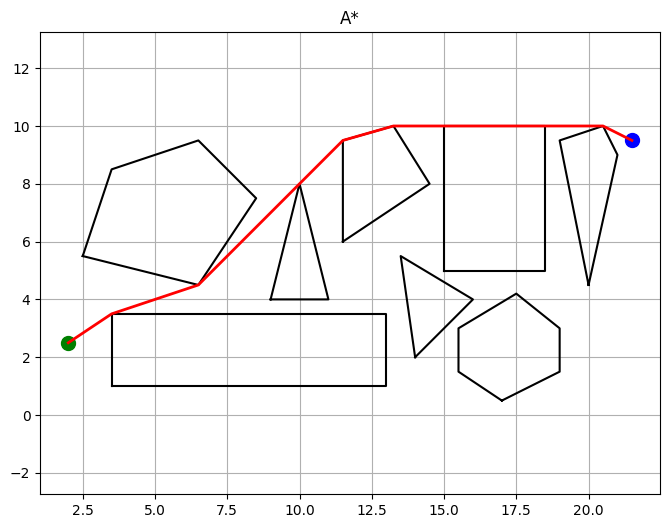


--- Uniform Cost Search ---
Path length: 8
Path cost: 22.224182570835872
Time: 0.0009453296661376953


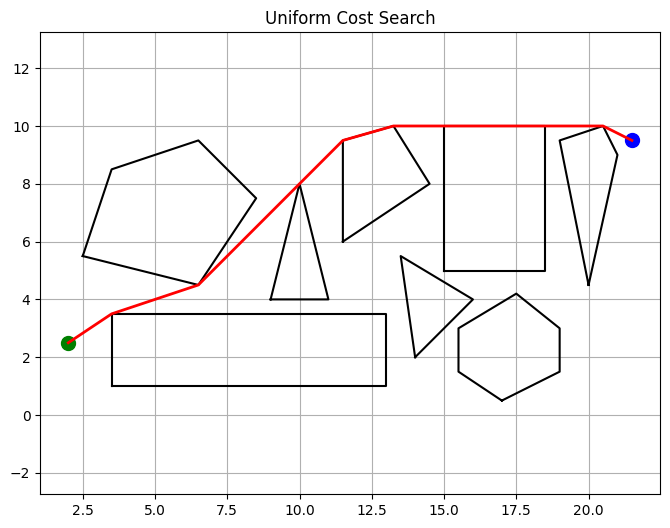


--- Greedy Best-First ---
Path length: 8
Path cost: 24.736497655666803
Time: 0.0004105567932128906


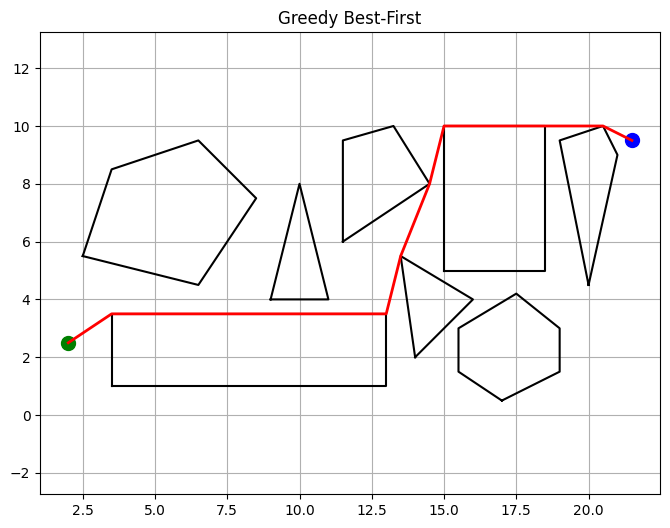

In [ ]:
# Scene
polygons = [
    [(3.5, 1.0), (13.0, 1.0), (13.0, 3.5), (3.5, 3.5)],
    [(2.5, 5.5), (3.5, 8.5), (6.5, 9.5), (8.5, 7.5), (6.5, 4.5)],
    [(9.0, 4.0), (11.0, 4.0), (10.0, 8.0)],
    [(11.5, 6.0), (14.5, 8.0), (13.25, 10), (11.5, 9.5)],
    [(15.0, 5.0), (18.5, 5.0), (18.5, 10.0), (15.0, 10.0)],
    [(14.0, 2.0), (16.0, 4.0), (13.5, 5.5)],
    [(17.0, 0.5), (19.0, 1.5), (19.0, 3), (17.5, 4.2), (15.5, 3), (15.5, 1.5)],
    [(20, 4.5), (21.0, 9), (20.5, 10.0), (19, 9.5)]
]


S = (2.0, 2.5)
G = (21.5, 9.5)

graph = build_visibility_graph(polygons, S, G)
problem = PolygonPathProblem(S, G, graph)


# Run algorithms
results = {}

def run_algo(name, func):
    start = time.time()
    solution = func(problem)
    elapsed = time.time() - start

    print(f"\n--- {name} ---")
    if solution:
        path = solution.path()
        cost = compute_path_cost(path)
        length = len(path)

        print("Path length:", length)
        print("Path cost:", cost)
        print("Time:", elapsed)

        plot_scene(polygons, graph, path, S, G, title=name)

        results[name] = {
            "time": elapsed,
            "cost": cost,
            "length": length
        }

run_algo("A*", astar_search)
run_algo("Uniform Cost Search", uniform_cost_search)
run_algo("Greedy Best-First", lambda p: greedy_best_first_graph_search(p, p.h))

# Exercise 3.9 - 4b

**4.b Comment on their performance.**

In this block, the performance results collected from the previous experiments are visualized using graphs. The execution time, path cost, and path length for each algorithm are displayed to make it easier to compare their behavior.

A\* and Uniform Cost Search both found the optimal solution, with the same path length and cost. However, A\* was slightly faster, likely due to the use of a heuristic to guide the search. Greedy Best-First Search was the fastest algorithm, but it produced a higher-cost (non-optimal) solution because it considers only the heuristic and ignores the actual path cost. This shows the trade-off between optimality and speed among the algorithms.


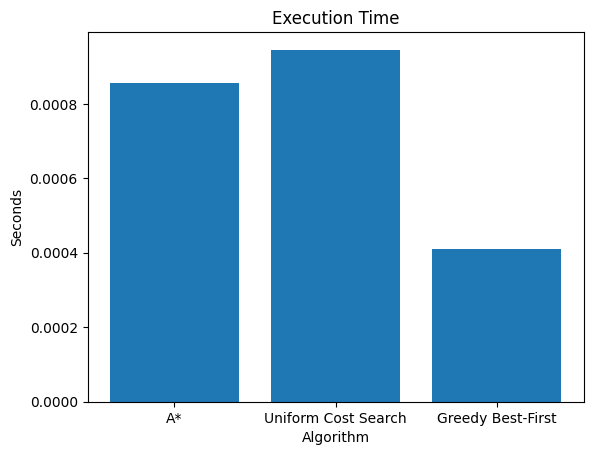

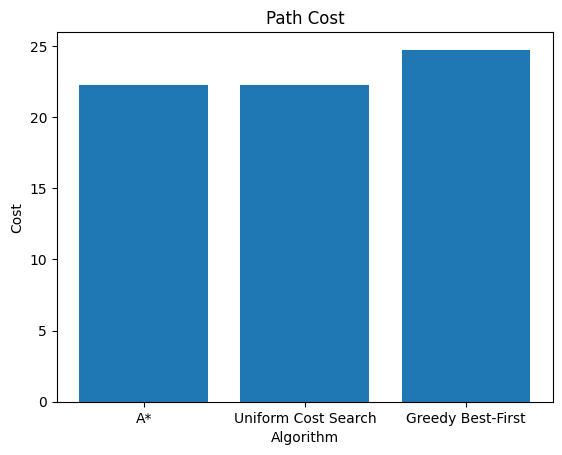

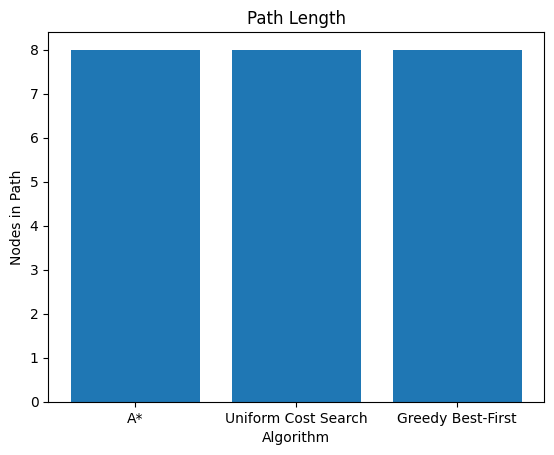

In [ ]:
# Performance Visualization
algorithms = list(results.keys())
times = [results[a]["time"] for a in algorithms]
costs = [results[a]["cost"] for a in algorithms]
lengths = [results[a]["length"] for a in algorithms]

# ---- Time ----
plt.figure()
plt.bar(algorithms, times)
plt.title("Execution Time")
plt.xlabel("Algorithm")
plt.ylabel("Seconds")
plt.show()
print()

# ---- Cost ----
plt.figure()
plt.bar(algorithms, costs)
plt.title("Path Cost")
plt.xlabel("Algorithm")
plt.ylabel("Cost")
plt.show()
print()

# ---- Length ----
plt.figure()
plt.bar(algorithms, lengths)
plt.title("Path Length")
plt.xlabel("Algorithm")
plt.ylabel("Nodes in Path")
plt.show()
print()

# Exercise 3.11 - 1
We formulate the missionaries and cannibals problem as a search problem using the AIMA `Problem` class. A state is represented as a tuple (M, C, B), where M and C are the number of missionaries and cannibals on the left side of the river, and B indicates the position of the boat.

The actions correspond to all valid combinations of one or two people crossing the river, and the transition model updates the state depending on the direction of the boat. A validity check ensures that missionaries are never outnumbered by cannibals on either side, which enforces the problem’s constraints.


In [ ]:
class MissionariesCannibals(Problem):
    def __init__(self):
        super().__init__((3, 3, 0))  # (M_left, C_left, boat)

    def goal_test(self, state):
        return state == (0, 0, 1)

    def actions(self, state):
        M, C, boat = state
        moves = [(1,0), (2,0), (0,1), (0,2), (1,1)]
        valid_actions = []

        for m, c in moves:
            if boat == 0:  # left → right
                new_state = (M - m, C - c, 1)
            else:          # right → left
                new_state = (M + m, C + c, 0)

            if self.is_valid(new_state):
                valid_actions.append((m, c))

        return valid_actions

    def result(self, state, action):
        M, C, boat = state
        m, c = action

        if boat == 0:
            return (M - m, C - c, 1)
        else:
            return (M + m, C + c, 0)

    def is_valid(self, state):
        M, C, _ = state
        M_r = 3 - M
        C_r = 3 - C

        # bounds
        if M < 0 or C < 0 or M > 3 or C > 3:
            return False

        # left side constraint
        if M > 0 and M < C:
            return False

        # right side constraint
        if M_r > 0 and M_r < C_r:
            return False

        return True


# Exercise 3.11 - 2
We implemented the problem using the AIMA `Problem` class and solved it using breadth-first search (BFS). BFS was chosen because all actions have equal cost and it guarantees an optimal solution (minimum number of crossings).

Checking for repeated states is important, since without it the search could revisit the same states (e.g., moving the boat back and forth), leading to loops. The graph search version of BFS avoids this by keeping track of explored states.


Solution (moves):
[(0, 2), (0, 1), (0, 2), (0, 1), (2, 0), (1, 1), (2, 0), (0, 1), (0, 2), (1, 0), (1, 1)]

State path:
(3, 3, 0)
(3, 1, 1)
(3, 2, 0)
(3, 0, 1)
(3, 1, 0)
(1, 1, 1)
(2, 2, 0)
(0, 2, 1)
(0, 3, 0)
(0, 1, 1)
(1, 1, 0)
(0, 0, 1)


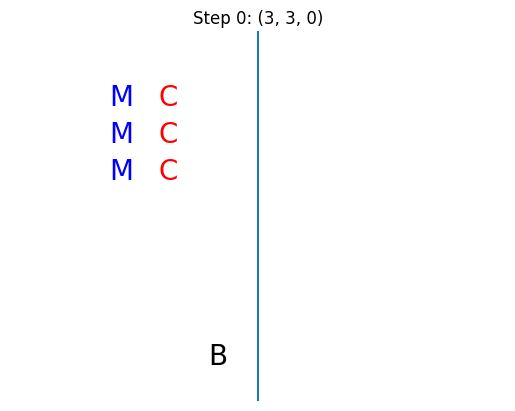

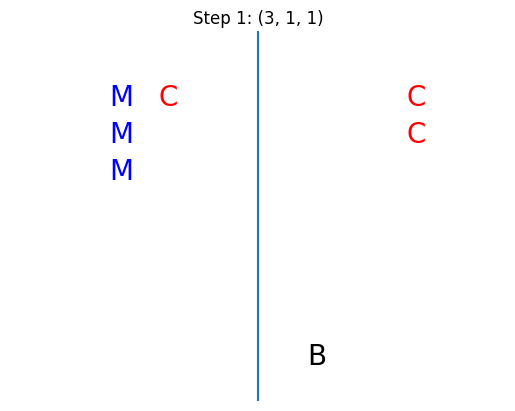

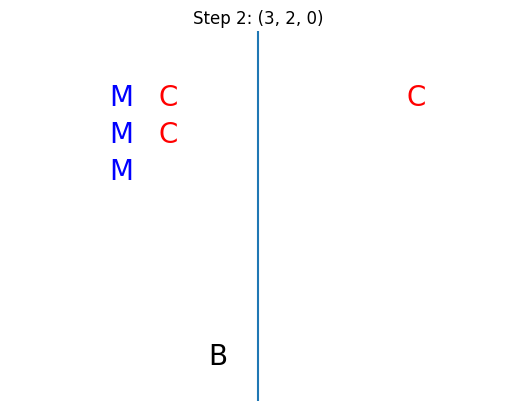

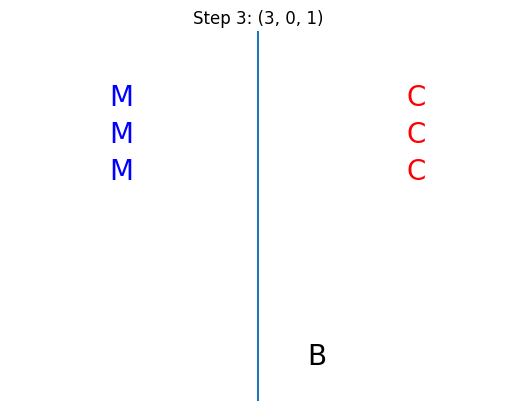

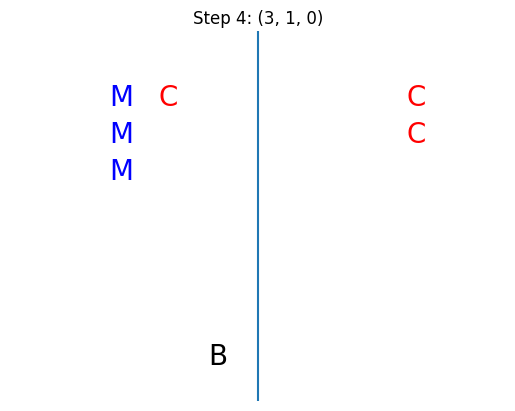

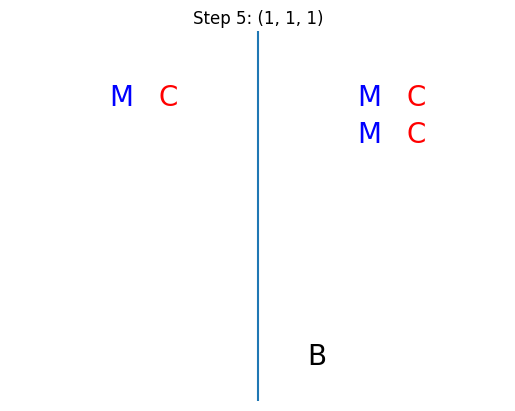

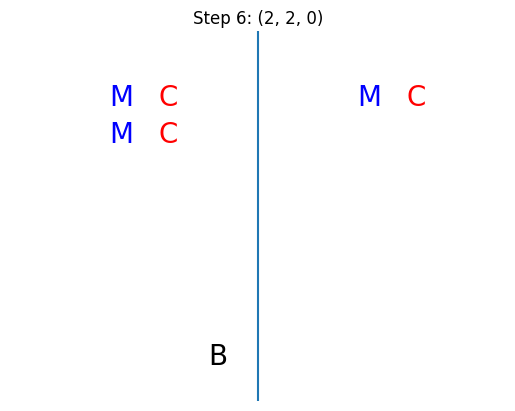

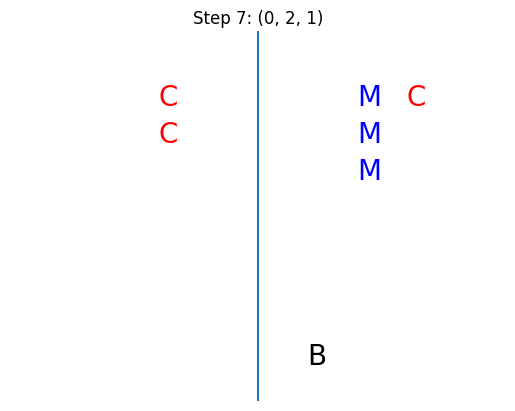

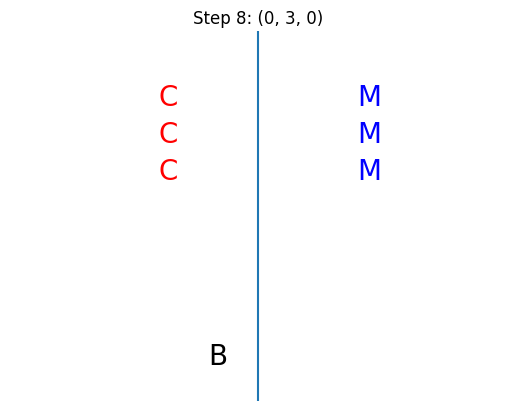

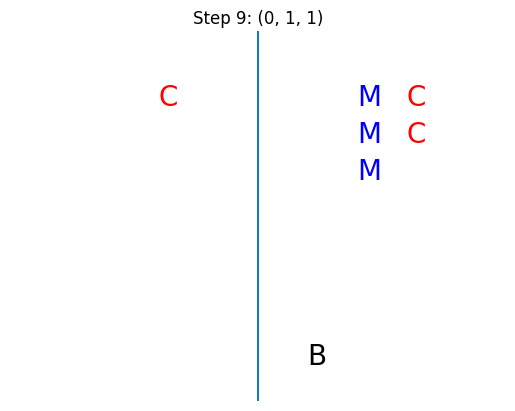

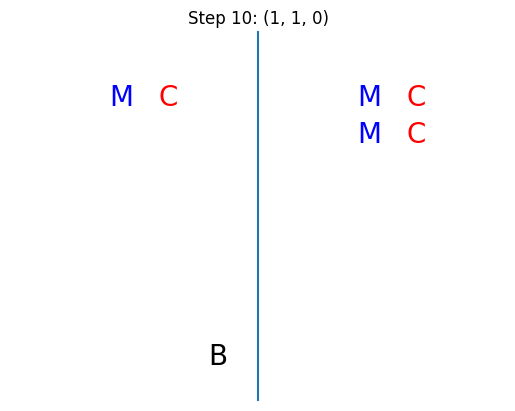

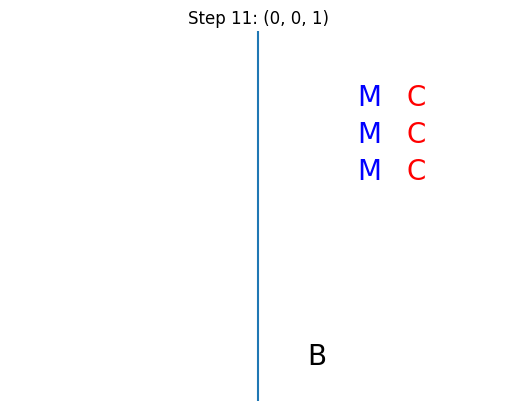

In [ ]:
import matplotlib.pyplot as plt

# Visualization (Drawing as required by 3.11 - 1)
def draw_state(state, step):
    M_left, C_left, boat = state
    M_right = 3 - M_left
    C_right = 3 - C_left

    plt.figure()

    # River divider
    plt.axvline(x=0.5)

    # LEFT SIDE
    for i in range(M_left):
        plt.text(0.2, 0.8 - i*0.1, "M", fontsize=20, color='blue')
    for i in range(C_left):
        plt.text(0.3, 0.8 - i*0.1, "C", fontsize=20, color='red')

    # RIGHT SIDE
    for i in range(M_right):
        plt.text(0.7, 0.8 - i*0.1, "M", fontsize=20, color='blue')
    for i in range(C_right):
        plt.text(0.8, 0.8 - i*0.1, "C", fontsize=20, color='red')

    # BOAT
    if boat == 0:
        plt.text(0.4, 0.1, "B", fontsize=20)
    else:
        plt.text(0.6, 0.1, "B", fontsize=20)

    plt.xlim(0, 1)
    plt.ylim(0, 1)
    plt.title(f"Step {step}: {state}")
    plt.axis('off')

    plt.show()
    print()


def show_solution(solution):
    for i, node in enumerate(solution.path()):
        draw_state(node.state, i)

# Run scenario using breath_first_
if __name__ == "__main__":
    problem = MissionariesCannibals()
    solution = breadth_first_graph_search(problem)

    print("Solution (moves):")
    print(solution.solution())

    print("\nState path:")
    for node in solution.path():
        print(node.state)

    # Show step-by-step images
    show_solution(solution)

# Exercise 3.11 - 3
**Why do you think people have a hard time solving this puzzle, given that the state space is so simple?**

Although the state space is small, people find this puzzle difficult because it requires keeping track of multiple constraints simultaneously, particularly ensuring that missionaries are never outnumbered on either side of the river. This makes even simple moves harder to evaluate.

In addition, solving the problem requires planning several steps ahead, since some valid moves may temporarily seem counterintuitive or appear to move away from the goal. Humans typically rely on intuition rather than systematically exploring all possible states, which can lead to mistakes or getting stuck, whereas search algorithms handle this process methodically.



# **Report : Project Assigment #4 - Search**

<br>

**University of Puerto Rico, Mayagüez Campus**  
**Electrical and Computer Engineering Department**

---

<br>

### Prepared by:
Jael A. Gonzalez De Arce  
Néstor O. Santos Torres  
Jayson D. Perez Ramirez  

<br>

### Date:
April 22nd, 2026

<br><br><br><br>

---

## Abstract

This report explores the formulation and solution of two classical artificial intelligence search problems: shortest path planning in a polygonal environment (Exercise 3.9) and the Missionaries and Cannibals problem (Exercise 3.11). Both problems were modeled using a common search framework based on the `Problem` abstraction, enabling the application of standard search algorithms.

In Exercise 3.9, a continuous geometric space was reduced to a finite visibility graph, allowing algorithms such as A\*, Uniform Cost Search, and Greedy Best-First Search to compute paths efficiently. The results highlight the role of heuristics in improving performance while maintaining optimality.

In Exercise 3.11, a constrained state-space representation was used to model valid configurations and transitions. The solution demonstrates how enforcing constraints during search ensures correctness and leads to an optimal sequence of actions.

Overall, this report emphasizes the importance of problem representation, state space design, and algorithm selection in effectively solving search problems in artificial intelligence.

---

## Table of Contents

I. [Introduction](#i-introduction)

II. [Theory](#ii-theory)

III. [Discussion](#iii-discussion)

IV. [Conclusion](#conclusion)

[References](#references)

---

## I. Introduction

Search algorithms are a core component of artificial intelligence, enabling an agent to determine a sequence of actions that leads from an initial state to a desired goal state. The effectiveness of a search algorithm depends not only on the algorithm itself but also on how the problem is formulated and represented [1].

In this assignment, two classical search problems are studied. Exercise 3.9 focuses on pathfinding in a plane with polygonal obstacles, a problem closely related to computational geometry and robotics navigation [2]. Exercise 3.11 examines a constrained state-space problem involving missionaries and cannibals crossing a river, a well-known benchmark for reasoning under constraints [3].

The goal of this project is to:

- Formulate each problem as a search problem using states, actions, and constraints  
- Apply appropriate search algorithms to obtain optimal solutions  
- Analyze how the structure of each problem affects search complexity and performance  

All implementations were carried out using the UC Berkeley AIMA Python repository, which provides a general framework for defining and solving search problems [4].

---

## II. Theory

Search problems are formally defined by a set of states, an initial state, a set of actions, and a goal test. Many formulations also include a path cost function used to evaluate solution quality [1]. In this report two exercises are discussed and evaluated.

### **Problem 3.9 - Shortest Path with Polygonal Obstacles**

In its original form, this problem considers all points (x, y) in the plane as valid states, resulting in a continuous and infinite state space. Such a formulation is not practical for standard search algorithms.

A key geometric principle simplifies the problem: in free space, the shortest path between two points is a straight line [2]. Therefore, any deviation from a straight path must be caused by obstacles.

It has been established in computational geometry that any turn in an optimal path around polygonal obstacles occurs at obstacle vertices. If a path bends at a non-vertex point, it can be adjusted along the obstacle boundary to pass through a vertex without increasing its length [2].

This observation reduces the state space to:
- the start point  
- the goal point  
- all polygon vertices  

If there are n vertices, the total number of states becomes n + 2.

A visibility graph is then constructed, where edges connect pairs of vertices that can be joined by a straight line without intersecting any obstacles. Shortest path algorithms such as A\* can then be applied to this graph.

A\* commonly uses Euclidean distance as a heuristic. This heuristic is admissible because it never overestimates the true shortest path between two points in the plane [1].

### **Problem 3.11 - Missionaries and Cannibals**

The Missionaries and Cannibals problem is a classical example of a constrained state-space search problem.

A state is represented as:

(M, C, B)

where M is the number of missionaries, C is the number of cannibals on the left bank, and B indicates the position of the boat.

The objective is to move all individuals to the opposite bank while ensuring that cannibals never outnumber missionaries on either side, unless no missionaries are present [3].

The state space is finite but constrained, meaning many theoretically possible states are invalid. Valid actions consist of transporting one or two individuals across the river, depending on the boat capacity.

Breadth-First Search (BFS) is commonly used to solve this problem because it guarantees the shortest solution in terms of the number of moves in an unweighted state space [1]. Additionally, repeated-state checking is required to prevent cycles and redundant exploration.

---

## III. Discussion

### **Hypothesis**
In Exercise 3.9, which involves finding shortest paths in a polygonal environment, it is expected that both A\* and Uniform Cost Search will produce optimal solutions, since both algorithms guarantee optimality when costs are positive. However, A\* should perform slightly faster due to the use of a heuristic (straight-line distance), which guides the search more directly toward the goal. In contrast, Greedy Best-First Search is expected to be faster than both A\* and Uniform Cost Search because it relies solely on the heuristic and ignores path cost, but this comes at the expense of optimality, meaning it may return a longer path.

For Exercise 3.11, the Missionaries and Cannibals problem, the expectation is that a properly defined state space and constraint handling will allow a search algorithm to find a valid sequence of moves that safely transports all individuals across the river. The hypothesis is that the solution found will satisfy all constraints and represent an optimal or near-optimal sequence in terms of number of moves.

### **Design Choices**

For both exercises, the problems were implemented as classes inheriting from the `Problem` abstraction provided by the UC Berkeley Pacman AI Project framework, allowing the use of standard search algorithms through a consistent interface.

In Exercise 3.9, the problem was defined through the `PolygonPathProblem` class, where the state space consists of polygon vertices, and transitions are given by a precomputed visibility graph. The methods `actions`, `result`, `goal_test`, `path_cost`, and a heuristic function `h` (based on Euclidean distance) were implemented to support A\*, Uniform Cost Search, and Greedy Best-First Search.

In Exercise 3.11, the `MissionariesCannibals` class was used to model the problem with states of the form (M, C, B). The implementation defined `actions` to generate valid boat moves, `result` to compute state transitions, `goal_test` to detect completion, and an `is_valid` helper to enforce safety constraints. This structure ensured that only valid states were explored during the search.

### **Mesurements**
The performance of the algorithms in Exercise 3.9 was evaluated using three main metrics: path length (number of nodes in the solution), total path cost (sum of Euclidean distances along the path), and execution time. These metrics allow for a comparison of both efficiency and optimality across the different search strategies.

For Exercise 3.11, the evaluation focused on the sequence of moves and the resulting state path. The primary concern was correctness, ensuring that all constraints were satisfied at every step, and completeness, meaning that all individuals successfully reached the goal state. The number of moves in the solution also serves as an indicator of efficiency.


### **Results and Analysis**
It is important to note that all of the results of the assigment are available as output within their corresponding code blocks. Due to the nature of Jupyter notebooks, we are not directly re-inserting the pictures (graphs, drawings, etc.) within the explanations to prevent formatting errors.

The results for Exercise 3.9 show that both A\* and Uniform Cost Search produced identical solutions, with a path length of `8` and a total cost of ~ `22.22`. This confirms that both algorithms are able to find optimal paths. In terms of performance, A\* was slightly faster, with a runtime of ~ `0.000856`, compared to Uniform Cost Search at ~ `0.000945`. This aligns with expectations, as the heuristic in A\* helps guide the search more efficiently.

Greedy Best-First Search achieved the fastest execution time at ~ `0.000410`, but produced a higher path cost of ~ `24.736`, even though the path length remained `8`. This indicates that while Greedy search is faster, it sacrifices optimality by ignoring accumulated path cost. The results clearly demonstrate the trade-off between speed and solution quality.

For Exercise 3.11, the algorithm produced a valid sequence of `11` moves that successfully transfers all missionaries and cannibals across the river. The state path confirms that all constraints are satisfied at every step, with no situation where missionaries are outnumbered by cannibals. The final state `(0, 0, 1)` verifies that the goal is reached correctly. This solution is consistent with the known optimal solution length, indicating both correctness and efficiency of the approach.

---

## Conclusion

This report demonstrated how classical search problems can be effectively solved by carefully formulating them within a structured search framework. In both exercises, the key to obtaining correct and efficient solutions was not only the choice of algorithm, but more importantly the way the problem was represented.

For Exercise 3.9, transforming a continuous geometric environment into a finite visibility graph made it possible to apply standard search algorithms. The results confirmed that A\* provides an efficient and optimal solution by leveraging a heuristic, while Uniform Cost Search guarantees optimality without guidance, and Greedy Best-First Search improves speed at the cost of solution quality. This highlights the importance of heuristics in balancing efficiency and optimality in search problems.

For Exercise 3.11, the problem illustrated how constraints significantly shape the state space. By defining valid states and enforcing rules through the transition model, the search was restricted to feasible solutions only. The algorithm successfully produced an optimal sequence of moves, demonstrating the effectiveness of proper state representation and constraint handling.

Overall, this assignment reinforces that successful problem solving in artificial intelligence depends on both algorithm selection and problem formulation. A well-designed representation can reduce complexity, improve performance, and enable general-purpose search algorithms to solve a wide range of problems effectively.

---

## References


[1] S. Russell and P. Norvig, *Artificial Intelligence: A Modern Approach*, 4th ed., Pearson, 2021.

[2] "Visibility graph," Wikipedia. Available: https://en.wikipedia.org/wiki/Visibility_graph

[3] "Missionaries and Cannibals Problem," GeeksforGeeks. Available: https://www.geeksforgeeks.org/missionaries-and-cannibals/

[4] "AIMA Python Repository," UC Berkeley. Available: https://github.com/aimacode/aima-python
